# 5. Modellierung der Daten

In [17]:
import hashlib
import json
import re
import time
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Memory, dump, load
from tqdm import tqdm
from pathlib import Path

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

sklearn_memory = Memory(
    location=project_root / "cache" / "sklearn",
    verbose=0,
)

model_output_dir = project_root / "models"
model_output_dir.mkdir(parents=True, exist_ok=True)

# Laufzeitsteuerung für optionale, rechenintensive Modellblöcke.
# CatBoost und BERT bleiben als optionale, rechenintensive Experimente standardmäßig deaktiviert.
RUN_CATBOOST_BASELINE = True
RUN_LOGREG_CONTROL_COMPARISON = False
RUN_BERT_BASELINE = False

CROSS_VALIDATION_N_JOBS = 1
MODEL_N_JOBS = 1


src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import model_evaluation
import model_evaluation.utils as model_evaluation_utils

importlib.reload(model_evaluation_utils)
importlib.reload(model_evaluation)

from model_evaluation import (
    create_model_signature,
    evaluate_existing_model_on_training_data,
    expected_model_path,
    fit_and_save_model,
    make_json_safe,
    safe_model_filename,
    set_default_model_output_dir,
    signed_model_artifact_exists,
    signed_result_exists,
)

set_default_model_output_dir(model_output_dir)

train_df = pd.read_csv(
    project_root / "data" / "processed" / "train_data.csv",
    sep=";",
    index_col=0,
    encoding="utf-8",
)

print("Train:", train_df.shape)

display(train_df.head())


Train: (45920, 28)


,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid,name_normalized,geber_normalized,art_normalized,anschrift_normalized,zweck_normalized,empfaengerid_normalized,name_standardised,geber_standardised,art_standardised,anschrift_standardised,zweck_standardised,empfaengerid_standardised,name_standardised_before_modelling,geber_standardised_before_modelling,art_standardised_before_modelling,anschrift_standardised_before_modelling,zweck_standardised_before_modelling,empfaengerid_standardised_before_modelling,betrag_standardised
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
33655,Cashmere Radio e. V.,Senatsverwaltung für Kultur und Gesellschaftlicher Zusammenhalt,Projektförderung,2024,"Frankfurter Allee 7, 10247 Berlin",Kultur,"signal2noise ? Art, Aesthetics And Social Practice Of Community Radios",120000,vr_035983,cashmere radio e. v.,senatsverwaltung für kultur und gesellschaftlicher zusammenhalt,projektförderung,"frankfurter allee 7, 10247 berlin","signal2noise ? art, aesthetics and social practice of community radios",vr_035983,cashmere radio e. v.,senatsverwaltung für kultur und gesellschaftlicher zusammenhalt,projektförderung,"frankfurter allee 7, 10247 berlin-bezirk friedrichshain-kreuzberg, deutschland","signal2noise ? art, aesthetics and social practice of community radios",vr_035983,cashmere radio e. v.,senatsverwaltung für kultur und gesellschaftlicher zusammenhalt,projektförderung,"Frankfurter Allee 7, 10247 Berlin-Bezirk Friedrichshain-Kreuzberg, Deutschland","signal2noise ? art, aesthetics and social practice of community radios",vr_035983,11.695255
105910,Merantix Labs GmbH,"Senatsverwaltung für Wirtschaft, Energie und Betriebe",Projektförderung,2022,"Max-Urich-Straße 3, 13355 Berlin",Wirtschaft,Errichtung einer Betriebsstätte,5481380,hrb_221397,merantix labs gmbh,"senatsverwaltung für wirtschaft, energie und betriebe",projektförderung,"max-urich-strasse 3, 13355 berlin",errichtung einer betriebsstätte,hrb_221397,merantix labs gmbh,"senatsverwaltung für wirtschaft, energie und betriebe",projektförderung,"c/o ai campus, fachbereich bionik und evolutionstechnik, max-urich-strasse 3, 13355 berlin, deutschland",errichtung einer betriebsstätte,hrb_221397,merantix labs gmbh,"senatsverwaltung für wirtschaft, energie und betriebe",projektförderung,"c/o AI Campus, Fachbereich Bionik und Evolutionstechnik, Max-Urich-Straße 3, 13355 Berlin, Deutschland",errichtung einer betriebsstätte,hrb_221397,15.516868
67465,Georg-Kolbe-Stiftung,Senatsverwaltung für Kultur und Europa,Projektförderung,2020,"Sensburger Allee 25, 14055 Berlin",Kultur,Der absolute Tanz- Festival sculpture,70000,spr_100011,georg-kolbe-stiftung,senatsverwaltung für kultur und europa,projektförderung,"sensburger allee 25, 14055 berlin",der absolute tanz- festival sculpture,spr_100011,georg kolbe-stiftung,senatsverwaltung für kultur und europa,projektförderung,"sensburger allee 25, 14055 berlin-bezirk charlottenburg-wilmersdorf, deutschland",der absolute tanz- festival sculpture,spr_100011,georg kolbe-stiftung,senatsverwaltung für kultur und europa,projektförderung,"Sensburger Allee 25, 14055 Berlin-Bezirk Charlottenburg-Wilmersdorf, Deutschland",der absolute tanz- festival sculpture,spr_100011,11.156265
159301,Verschiedene Gesellschaften bürgerlichen Rechts,"Senatsverwaltung für Inneres, Digitalisierung und Sport",Projektförderung,2023,'---',Sport,Kosten für die Beschäftigung von Übungsleitern,1380,NaN,verschiedene gesellschaften bürgerlichen rechts,"senatsverwaltung für inneres, digitalisierung und sport",projektförderung,'---',kosten für die beschäftigung von übungsleitern,NaN,verschiedene gesellschaften bürgerlichen rechts,"senatsverwaltung für inneres, digitalisierung und sport",projektförderung,deutschland,kosten für die beschäftigung von übungsleitern,NaN,verschiedene gesellschaften bürgerlichen rechts,"senatsverwaltung für inneres, digitalisierung und sport",projektförderung,Deutschland,kosten für die beschäftigung von übungsleitern,NaN,7.230563
19495,Ber

## 5.1. Vorbereitung der Modellierung

Die Vorverarbeitung wird als scikit-learn `Pipeline` aufgebaut, weil dadurch alle lernenden Schritte innerhalb der Cross-Validation nur auf den jeweiligen Trainingsdaten angepasst werden. Das reduziert das Risiko von Data Leakage.

### 5.1.1. Zielvariable und Eingabemerkmale trennen

Zuerst werden Zielvariable und Eingabemerkmale getrennt. Als Zielvariable wird `politikbereich` verwendet. Für die Eingabemerkmale werden die bereits bereinigten und standardisierten Textspalten, die numerischen Spalte `betrag` sowie kategorische Spalten `art` und `jahr` genutzt. Die Empfänger-ID wird hier bewusst nicht als direktes Modellmerkmal verwendet, weil sie stark organisationsspezifisch ist und das Modell sonst eher bekannte Empfänger memorisieren könnte.


In [18]:
target_column = "politikbereich"

text_features = [
    "name_standardised",
    "geber_standardised",
    "anschrift_standardised",
    "zweck_standardised",
]

numeric_features = [
    "betrag",
]

categorical_features = [
    "art_standardised",
    "jahr",
]

feature_columns = text_features + numeric_features + categorical_features

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

missing_feature_values = (
    X_train
    .isna()
    .sum()
    .rename("missing_values")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(missing_feature_values)


,feature,missing_values
0,name_standardised,0
1,geber_standardised,0
2,anschrift_standardised,0
3,zweck_standardised,1
4,betrag,0
5,art_standardised,0
6,jahr,0


### 5.1.2. Textspalten vorbereiten

Die Textspalten können nicht direkt von klassischen scikit-learn-Modellen verarbeitet werden. Deshalb werden sie in TF-IDF-Merkmale umgewandelt. TF-IDF ist für diese Aufgabe geeignet, weil nicht nur das Vorkommen eines Wortes zählt, sondern auch seine Spezifität innerhalb des gesamten Korpus. Sehr seltene Terme werden mit `min_df=2` entfernt, da sie häufig Tippfehler oder Einzelfälle darstellen. Sehr häufige Terme werden mit `max_df=0.90` reduziert, weil sie meist wenig trennscharf sind. Mit `ngram_range=(1, 2)` werden zusätzlich Wortpaare berücksichtigt, z. B. fachlich relevante Ausdrücke wie „soziale stadt“.


TF: Term Frequency
IDF: Inverse Document Frequency

In [19]:
def flatten_column(values):
    """Convert a single-column 2D array into a 1D string array."""
    return np.asarray(values, dtype=object).ravel()


text_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="",
            ),
        ),
        (
            "flatten",
            FunctionTransformer(
                flatten_column,
                validate=False,
            ),
        ),
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                max_df=0.90,
                ngram_range=(1, 2),
                sublinear_tf=True,
                max_features=30_000,
                dtype=np.float32,
            ),
        ),
    ]
)

### 5.1.3. Numerische Spalten vorbereiten

Die numerischen Merkmale werden getrennt von den Textspalten verarbeitet. Fehlende Werte werden mit dem Median ersetzt, weil der Median robuster gegenüber extremen Förderbeträgen ist als der Mittelwert. Anschließend werden die numerischen Werte standardisiert. Das ist besonders für lineare Modelle wichtig, weil Merkmale mit großer Skala sonst einen unverhältnismäßig starken Einfluss bekommen können.


In [20]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


### 5.1.3. Kategorische Spalten vorbereiten


Für die kategorialen Merkmale werden in diesem Notebook `art_standardised` und `jahr` verwendet. Die Spalte `art_standardised` beschreibt die Art der Förderung und besitzt keine natürliche numerische Reihenfolge. Auch `jahr` wird in diesem Modellierungsansatz nicht als kontinuierliche Zahl behandelt, sondern als diskrete Kategorie. Dadurch kann das Modell jahresspezifische Unterschiede berücksichtigen, ohne eine lineare zeitliche Entwicklung zwischen den Jahren vorauszusetzen.

Die Verarbeitung erfolgt mit einer scikit-learn `Pipeline`. Zunächst werden fehlende Werte mit `SimpleImputer(strategy="most_frequent")` durch die häufigste Kategorie ersetzt. Danach werden die Kategorien mit `OneHotEncoder` in binäre Merkmale umgewandelt. Für jede Ausprägung entsteht dadurch eine eigene Indikatorspalte. So kann das Modell kategoriale Informationen nutzen, ohne dass eine künstliche Ordnung zwischen den Kategorien entsteht.

Mit `handle_unknown="ignore"` bleibt die Pipeline außerdem stabil, falls in späteren Daten eine Kategorie auftritt, die im Training nicht vorhanden war. Diese unbekannte Kategorie führt dann nicht zu einem Fehler, sondern wird in der One-Hot-Repräsentation ignoriert.

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

### 5.1.4. Spaltenspezifische Vorverarbeitung zusammenführen

Da Text- und numerische Spalten unterschiedliche Verarbeitung benötigen, werden sie mit einem `ColumnTransformer` zusammengeführt. Jede Textspalte erhält eine eigene TF-IDF-Repräsentation, damit der Kontext der jeweiligen Spalte erhalten bleibt. Der Förderzweck, der Geber und der Empfängername werden dadurch nicht zu einem einzigen Textblock vermischt, sondern als getrennte Informationsquellen behandelt.


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            f"tfidf_{column}",
            text_transformer,
            [column],
        )
        for column in text_features
    ]
    + [
        (
            "numeric",
            numeric_transformer,
            numeric_features,
        )
    ]
    + [
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        )
    ],
    remainder="drop",
)

print("Preprocessor definiert f\u00fcr", len(feature_columns), "Eingabespalten.")

Preprocessor definiert für 7 Eingabespalten.


## 5.2. Evaluationsrahmen vorbereiten

Wegen der Klassenunverteilung wird die spätere Modellbewertung nicht nur über Accuracy erfolgen. Accuracy zeigt zwar den Anteil aller korrekt vorhergesagten Fälle, kann bei unausgewogenen Klassen jedoch stark durch große Klassen dominiert werden. Deshalb werden zusätzliche Metriken verwendet, die die Leistung über alle Politikbereiche hinweg differenzierter bewerten.

Der Macro-F1-Score wird als Hauptmetrik verwendet, da er jede Klasse gleich stark gewichtet und dadurch auch Probleme bei kleinen Klassen sichtbar macht. Der Weighted-F1-Score ergänzt diese Sicht, indem er die tatsächliche Klassenhäufigkeit berücksichtigt. Zusätzlich wird Balanced Accuracy verwendet, weil sie die durchschnittliche Erkennungsrate über alle Klassen hinweg misst.

Metriken pro Klasse und die Konfusionsmatrix werden nicht direkt im Cross-Validation-Scoring berechnet, sondern später bei der detaillierten Modellbewertung ergänzt. Sie helfen dabei zu erkennen, welche Politikbereiche besonders häufig falsch klassifiziert werden und welche Klassen vom Modell kaum erkannt werden.

| Metrik | Zweck |
|---|---|
| **Macro-F1** | Gleichwertige Bewertung aller Klassen |
| **Weighted-F1** | Bewertung entsprechend der Klassenhäufigkeit |
| **Balanced Accuracy** | Durchschnittliche Erkennungsrate aller Klassen |
| **Accuracy** | Anteil aller korrekten Vorhersagen |
| **Metriken pro Klasse** | Erkennung problematischer Klassen |
| **Konfusionsmatrix** | Darstellung typischer Verwechslungen |

In [23]:
min_class_count = y_train.value_counts().min()
n_splits = min(4, min_class_count)

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42,
)

print("Vorbereitete CV-Folds:", n_splits)

Vorbereitete CV-Folds: 4


In [24]:
scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

main_metric = "macro_f1"

signature_run_config = {
    "cv_strategy": "StratifiedKFold",
    "n_splits": n_splits,
    "shuffle": True,
    "random_state": 42,
    "scoring": list(scoring.keys()),
    "main_metric": main_metric,
    "text_features": text_features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
}

print("Hauptmetrik:", main_metric)
print("Verwendete Metriken:", list(scoring.keys()))
print("Signatur-Konfiguration:", signature_run_config)

Hauptmetrik: macro_f1
Verwendete Metriken: ['macro_f1', 'weighted_f1', 'balanced_accuracy', 'accuracy']
Signatur-Konfiguration: {'cv_strategy': 'StratifiedKFold', 'n_splits': 4, 'shuffle': True, 'random_state': 42, 'scoring': ['macro_f1', 'weighted_f1', 'balanced_accuracy', 'accuracy'], 'main_metric': 'macro_f1', 'text_features': ['name_standardised', 'geber_standardised', 'anschrift_standardised', 'zweck_standardised'], 'categorical_features': ['art_standardised', 'jahr'], 'numeric_features': ['betrag']}


In [25]:
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     classification_report,
#     ConfusionMatrixDisplay,
# )


# def create_classification_report_df(
#     y_true,
#     y_pred,
# ):
#     """Erstellt einen DataFrame mit den Metriken pro Klasse."""
#     report_df = pd.DataFrame(
#         classification_report(
#             y_true,
#             y_pred,
#             output_dict=True,
#             zero_division=0,
#         )
#     ).transpose()

#     return report_df


# def plot_confusion_matrix(
#     y_true,
#     y_pred,
#     title="Konfusionsmatrix",
#     figsize=(14, 14),
# ):
#     """Visualisiert die Verwechslungen zwischen den Klassen."""
#     fig, ax = plt.subplots(figsize=figsize)

#     ConfusionMatrixDisplay.from_predictions(
#         y_true,
#         y_pred,
#         xticks_rotation=90,
#         ax=ax,
#     )

#     ax.set_title(title)

#     plt.tight_layout()
#     plt.show()

## 5.3. Geeignete Modellhypothesen für den Politikbereich-Klassifikator

Die Aufgabe ist eine mehrklassige Klassifikation des `politikbereich`. Die Eingabedaten bestehen aus mehreren bereinigten Textspalten, kategorialen Merkmalen und numerischen Informationen. Gleichzeitig ist die Zielvariable deutlich unausgewogen. Deshalb werden zunächst Modelle gewählt, die einerseits mit hochdimensionalen Textmerkmalen umgehen können und andererseits eine robuste, nachvollziehbare Vergleichsbasis liefern.

Die Modellhypothesen werden in drei Gruppen getrennt. **Klassische lineare Modelle** werden zuerst umgesetzt, weil sie schnell, reproduzierbar und gut mit Cross-Validation kombinierbar sind. **Tabellarische Modelle für gemischte Merkmale** werden zusätzlich geprüft, weil der Datensatz neben Text auch kategoriale und numerische Informationen enthält. **NLP- bzw. Deep-Learning-Modelle** werden als spätere Erweiterung betrachtet, da sie deutlich mehr Rechenzeit, zusätzliche Trainingslogik und häufig eine separate Validierungsstrategie benötigen.

#### Klassische lineare Modelle

| Modellkandidat | Begründung für diesen Datensatz | Rolle im Projekt |
|---|---|---|
| **Dummy Classifier** | Sagt nur die häufigste Klasse voraus und nutzt keine Eingabemerkmale. Dadurch entsteht ein einfacher Mindestvergleichswert für alle echten Modelle. | Referenzmodell |
| **Linear SVM / LinearSVC mit TF-IDF** | Textdaten mit TF-IDF erzeugen sehr viele sparse Merkmale. Lineare SVMs gelten als besonders geeignet für hochdimensionale Textklassifikationsprobleme. Es werden Varianten mit und ohne Klassengewichtung sowie unterschiedlicher Regularisierung getestet. | Starker klassischer Benchmark |
| **SGDClassifier mit Hinge Loss** | Approximiert eine lineare SVM mit stochastischem Gradientenverfahren. Diese Variante kann bei großen sparse Textdaten rechnerisch schneller sein als `LinearSVC`. | Effiziente SVM-Alternative |
| **SGDClassifier mit Log Loss** | Verwendet stochastisches Gradientenverfahren für eine logistische Regression. Damit dient das Modell als schnelle, skalierbare Variante der logistischen Regression. | Schnelle logistische Baseline |
| **Logistische Regression mit TF-IDF** | Ebenfalls ein starker linearer Textklassifikator, liefert gut interpretierbare Koeffizienten und unterstützt Klassengewichtung. | Interpretierbare lineare Baseline |
| **Complement Naive Bayes** | Sehr schneller Textklassifikator, der speziell als Verbesserung von Naive Bayes für unausgewogene Textdaten vorgeschlagen wurde. Da numerische und kategoriale Zusatzmerkmale nur eingeschränkt zu Naive Bayes passen, wird dieses Modell als textbasierte Zusatzbaseline betrachtet. | Schnelle einfache Textbaseline |

#### Tabellarische Modelle für gemischte Merkmale

| Modellkandidat | Begründung für diesen Datensatz | Rolle im Projekt |
|---|---|---|
| **CatBoost** | CatBoost kann kategoriale Merkmale direkt verarbeiten und unterstützt zusätzlich Textmerkmale. Dadurch eignet sich das Modell als Vergleich zu den linearen TF-IDF-Modellen, weil `name`, `geber`, `anschrift`, `zweck`, `art`, `jahr` und `betrag` gemeinsam in einer Modellfamilie genutzt werden können. | Nicht-lineare Mixed-Feature-Baseline |

#### NLP- und Deep-Learning-Modelle

| Modellkandidat | Begründung für diesen Datensatz | Rolle im Projekt |
|---|---|---|
| **fastText** | Effizientes Textklassifikationsmodell auf Basis von Wort- und n-Gramm-Repräsentationen. Da es nicht direkt in die bestehende scikit-learn-Pipeline passt, wird es als separater NLP-Vergleich betrachtet. | Effiziente NLP-Alternative |
| **German BERT / multilingual BERT** | Transformer-Modelle können semantischen Kontext besser erfassen als reine TF-IDF-Modelle. Sie sind jedoch rechenintensiver, benötigen Tokenisierung und Fine-Tuning und sind weniger direkt interpretierbar. | Erweiterte Deep-Learning-Hypothese bei ausreichender Zeit |

Für dieses Projekt ist es sinnvoll, zuerst mit den klassischen TF-IDF-basierten Modellen zu beginnen. Diese Modelle liefern eine transparente Vergleichsbasis und zeigen, wie weit man mit gut kontrollierbaren linearen Verfahren kommt. Ergänzend wird CatBoost als nicht-lineares Modell für gemischte Merkmale geprüft. fastText und BERT werden nicht als erste Baseline, sondern als spätere NLP-Erweiterung eingeordnet.

Die SVM-Varianten prüfen den Einfluss von Regularisierung und Klassengewichtung. Der `SGDClassifier(loss="hinge")` wird als rechnerisch effiziente SVM-Alternative aufgenommen. Der `SGDClassifier(loss="log_loss")` ergänzt dies als schnelle logistische Variante. CatBoost prüft dagegen, ob die gemeinsame Nutzung von Text-, Kategorie- und Zahlenmerkmalen zusätzliche nicht-lineare Muster sichtbar macht.

Wichtig ist, dass der Modellvergleich nicht primär über Accuracy erfolgt. Wegen der Klassenunverteilung wird der **Macro-F1-Score** als Hauptmetrik verwendet. Zusätzlich werden Weighted-F1, Balanced Accuracy, Metriken pro Klasse, Konfusionsmatrix sowie die Trainingszeit betrachtet.

Literaturhinweise:

- Joachims, T. (1998): *Text Categorization with Support Vector Machines*. https://www.cs.cornell.edu/people/tj/publications/joachims_98a.pdf
- Fan, R.-E. et al. (2008): *LIBLINEAR: A Library for Large Linear Classification*. https://www.jmlr.org/papers/v9/fan08a.html
- scikit-learn Dokumentation: `SGDClassifier`. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
- Prokhorenkova, L. et al. (2018): *CatBoost: unbiased boosting with categorical features*. https://arxiv.org/abs/1706.09516
- Rennie, J. D. M. et al. (2003): *Tackling the Poor Assumptions of Naive Bayes Text Classifiers*. https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf
- Joulin, A. et al. (2017): *Bag of Tricks for Efficient Text Classification*. https://aclanthology.org/E17-2068/
- Devlin, J. et al. (2019): *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. https://aclanthology.org/N19-1423/
- Wahba, Y. et al. (2022): *A Comparison of SVM against Pre-trained Language Models for Text Classification Tasks*. https://arxiv.org/abs/2211.02563

## 5.4. Definition der Modelle

In diesem Schritt werden die ersten Modellkandidaten definiert, aber noch nicht trainiert. Die meisten Modelle verwenden dieselbe Vorverarbeitung aus Abschnitt 5.1, damit die Ergebnisse später fair miteinander verglichen werden können. Dabei werden Textspalten mit TF-IDF verarbeitet, kategoriale Merkmale One-Hot-codiert und numerische Merkmale skaliert.

Der `DummyClassifier` dient als einfache Referenz. Er zeigt, welche Leistung ein Modell ohne echte Mustererkennung erreicht. Darauf aufbauend werden mehrere lineare Textmodelle definiert. Die `LinearSVC`-Modelle bilden starke klassische SVM-Benchmarks für hochdimensionale sparse TF-IDF-Merkmale. Dabei werden Klassengewichtung und Regularisierung variiert. Ein kleineres `C` bedeutet stärkere Regularisierung und kann bei sehr vielen TF-IDF-Merkmalen zu stabilerer Optimierung führen.

Zusätzlich wird `SGDClassifier(loss="hinge")` als schnelle SVM-nahe Alternative aufgenommen. Dieses Modell approximiert eine lineare SVM mit stochastischem Gradientenverfahren und kann bei großen sparse Matrizen schneller trainieren als `LinearSVC`. Der `SGDClassifier(loss="log_loss")` ergänzt dies als schnelle logistische Variante, weil er eine logistische Verlustfunktion mit stochastischem Gradientenverfahren optimiert.

Die reguläre logistische Regression bleibt als interpretierbare lineare Baseline enthalten. `ComplementNB` wird als sehr schnelle textbasierte Zusatzbaseline aufgenommen. Da dieses Modell besonders für sparse, nicht-negative Textmerkmale wie TF-IDF geeignet ist, wird es bewusst nur mit den Textspalten verwendet.

CatBoost wird nicht in die scikit-learn-`Pipeline` der linearen Modelle aufgenommen, weil es Text-, kategoriale und numerische Merkmale mit einer eigenen Datenstruktur (`Pool`) verarbeitet. Deshalb wird CatBoost im Baseline-Abschnitt separat, aber mit denselben Metriken und demselben Cross-Validation-Split evaluiert. Dadurch bleibt der Vergleich methodisch konsistent, während CatBoost seine eigene Verarbeitung gemischter Merkmalsarten nutzen kann.

### 5.4.1 Klassischen ML-Modelle

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


text_only_preprocessor = ColumnTransformer(
    transformers=[
        (
            f"tfidf_{column}",
            text_transformer,
            [column],
        )
        for column in text_features
    ],
    remainder="drop",
)


models = {
    "Dummy Classifier": Pipeline(
        steps=[
            (
                "classifier",
                DummyClassifier(
                    strategy="most_frequent",
                    random_state=42,
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "Linear SVC unweighted": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                LinearSVC(
                    class_weight=None,
                    random_state=42,
                    C=0.1,
                    max_iter=20000,
                    tol=1e-3,
                    dual="auto",
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "Linear SVC balanced": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                LinearSVC(
                    class_weight="balanced",
                    random_state=42,
                    C=0.05,
                    max_iter=30000,
                    tol=1e-3,
                    dual="auto",
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "SGD hinge balanced": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                SGDClassifier(
                    loss="hinge",
                    penalty="l2",
                    alpha=1e-4,
                    class_weight="balanced",
                    max_iter=1000,
                    tol=1e-3,
                    random_state=42,
                    n_jobs=MODEL_N_JOBS,
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "SGD log loss balanced": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                SGDClassifier(
                    loss="log_loss",
                    penalty="l2",
                    alpha=1e-4,
                    class_weight="balanced",
                    max_iter=1000,
                    tol=1e-3,
                    random_state=42,
                    n_jobs=MODEL_N_JOBS,
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "Logistic Regression balanced": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    solver="saga",
                    penalty="l2",
                    C=1.0,
                    max_iter=800,
                    tol=5e-3,
                    n_jobs=MODEL_N_JOBS,
                    random_state=42,
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
    "Complement Naive Bayes text only": Pipeline(
        steps=[
            (
                "preprocessor",
                text_only_preprocessor,
            ),
            (
                "classifier",
                ComplementNB(
                    alpha=1.0,
                ),
            ),
        ],
        memory=sklearn_memory,
    ),
}

model_overview = pd.DataFrame(
    [
        {
            "Modell": model_name,
            "Classifier": model.named_steps["classifier"].__class__.__name__,
            "Verwendet_Preprocessing": "preprocessor" in model.named_steps,
        }
        for model_name, model in models.items()
    ]
)

display(model_overview)


,Modell,Classifier,Verwendet_Preprocessing
0,Dummy Classifier,DummyClassifier,False
1,Linear SVC unweighted,LinearSVC,True
2,Linear SVC balanced,LinearSVC,True
3,SGD hinge balanced,SGDClassifier,True
4,SGD log loss balanced,SGDClassifier,True
5,Logistic Regression balanced,LogisticRegression,True
6,Complement Naive Bayes text only,ComplementNB,True


## 5.5. Baseline Cross-Validation mit MLflow

In diesem Abschnitt werden die zuvor definierten Baseline-Modelle mit derselben Cross-Validation und denselben Metriken bewertet. Ziel ist nicht die finale Modelloptimierung, sondern ein fairer erster Vergleich der Modellklassen.

MLflow wird dabei als Experiment-Tracking-Werkzeug verwendet. Es speichert für jeden Modelllauf die wichtigsten Parameter, Metriken und Ergebnisdateien. Dadurch bleiben die Experimente reproduzierbar und später vergleichbar, auch wenn weitere Modelle oder Optuna-Tuning hinzukommen.


### 5.5.1. MLflow vorbereiten

Zuerst wird ein lokaler MLflow-Tracking-Ordner im Projektverzeichnis definiert. Alle Baseline-Ergebnisse werden unter demselben Experimentnamen gespeichert. So lassen sich die Läufe später über die MLflow UI vergleichen.


In [27]:
import tempfile

import mlflow
from sklearn.model_selection import cross_validate


mlflow_tracking_dir = project_root / "mlruns"
mlflow.set_tracking_uri(mlflow_tracking_dir.as_uri())
mlflow.set_experiment("politikbereich_classifier")

print("MLflow Tracking URI:", mlflow.get_tracking_uri())
print("MLflow Experiment: politikbereich_classifier")


MLflow Tracking URI: file:///d:/toydev/schwarz-test/mlruns
MLflow Experiment: politikbereich_classifier


### 5.5.2. Hilfsfunktionen für Logging und Auswertung

Die folgenden Funktionen kapseln die wiederkehrenden Schritte. Für jedes Modell werden die Cross-Validation-Ergebnisse berechnet, Mittelwert und Standardabweichung der Metriken gebildet und anschließend in MLflow gespeichert. Zusätzlich wird die detaillierte Fold-Auswertung als CSV-Artefakt abgelegt.


In [28]:
# Die wiederverwendbaren CV-Hilfsfunktionen werden aus src/model_evaluation importiert.
from model_evaluation import (
    concat_non_empty_dataframes,
    display_model_evaluation_table,
    create_classification_report_df,
    create_cv_fold_results_df,
    create_cv_summary_row,
    ensure_val_metric_aliases,
    select_validation_result_columns,
)

def log_baseline_run(
    model_name,
    model,
    summary_row,
    fold_results,
):
    """Speichert Parameter, Metriken und Fold-Ergebnisse in MLflow."""
    classifier = model.named_steps["classifier"]

    with mlflow.start_run(run_name=model_name):
        mlflow.set_tag("stage", "baseline_cross_validation")
        mlflow.set_tag("main_metric", main_metric)

        mlflow.log_params(
            {
                "model_name": model_name,
                "model_signature": summary_row.get("model_signature"),
                "classifier": classifier.__class__.__name__,
                "uses_preprocessor": "preprocessor" in model.named_steps,
                "n_train_rows": len(X_train),
                "n_classes": y_train.nunique(),
                "cv_folds": n_splits,
                "text_features": ", ".join(text_features),
                "categorical_features": ", ".join(categorical_features),
                "numeric_features": ", ".join(numeric_features),
            }
        )

        for parameter_name, parameter_value in classifier.get_params().items():
            if parameter_name in [
                "alpha",
                "class_weight",
                "C",
                "dual",
                "loss",
                "penalty",
                "solver",
                "strategy",
                "max_iter",
                "tol",
                "random_state",
            ]:
                mlflow.log_param(
                    f"classifier__{parameter_name}",
                    str(parameter_value),
                )

        metric_columns = [
            column
            for column in summary_row.index
            if column.endswith("_mean")
            or column.endswith("_std")
            or column.endswith("_seconds")
        ]

        for metric_name in metric_columns:
            metric_value = summary_row[metric_name]

            if pd.notna(metric_value):
                mlflow.log_metric(
                    metric_name,
                    float(metric_value),
                )

        with tempfile.TemporaryDirectory() as temporary_directory:
            artifact_path = (
                Path(temporary_directory)
                / "cv_fold_results.csv"
            )

            fold_results.to_csv(
                artifact_path,
                index=False,
                sep=";",
                encoding="utf-8",
            )

            mlflow.log_artifact(
                str(artifact_path),
                artifact_path="cross_validation",
            )

### 5.5.3. Baseline-Modelle evaluieren

Nun werden alle definierten Baseline-Modelle mit derselben stratifizierten Cross-Validation bewertet. Falls für ein Modell bereits ein gespeichertes Ergebnis existiert, wird dieses wiederverwendet und das Modell wird nicht erneut trainiert. Neue Modelle werden berechnet und anschließend an die bestehenden Ergebnisdateien angehängt.

Zusätzlich werden `fit_time` und `score_time` gespeichert. Dadurch kann nicht nur die Modellgüte, sondern auch der Rechenaufwand der einzelnen Modellvarianten verglichen werden. Der Testdatensatz wird hier weiterhin nicht verwendet. Er bleibt für die finale Bewertung des ausgewählten Modells reserviert.


Variable / Ergebnisse definieren

In [29]:
from model_evaluation import (
    concat_non_empty_dataframes,
    display_model_evaluation_table,
    create_cv_fold_results_df,
    create_cv_summary_row,
    ensure_val_metric_aliases,
    select_validation_result_columns,
)

baseline_results_path = (
    project_root
    / "data"
    / "processed"
    / "baseline_cv_results.csv"
)

baseline_fold_results_path = (
    project_root
    / "data"
    / "processed"
    / "baseline_cv_fold_results.csv"
)

if baseline_results_path.exists():
    existing_baseline_results = pd.read_csv(
        baseline_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    existing_baseline_results = pd.DataFrame()

if baseline_fold_results_path.exists():
    existing_fold_results = pd.read_csv(
        baseline_fold_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    existing_fold_results = pd.DataFrame()

required_summary_columns = [
    "model_signature",
    "fit_time_total_seconds",
    "fit_time_mean_seconds",
    "fit_time_std_seconds",
    "score_time_mean_seconds",
]

for column in required_summary_columns:
    if column not in existing_baseline_results.columns:
        existing_baseline_results[column] = pd.NA

required_fold_columns = [
    "model_signature",
    "fit_time_seconds",
    "score_time_seconds",
]

for column in required_fold_columns:
    if column not in existing_fold_results.columns:
        existing_fold_results[column] = pd.NA

new_baseline_rows = []
new_fold_results = []

print("Bestehende Baseline-Ergebnisse:", len(existing_baseline_results))
print("Bestehende Fold-Ergebnisse:", len(existing_fold_results))

Bestehende Baseline-Ergebnisse: 7
Bestehende Fold-Ergebnisse: 28


Trainig / CV / Modell Speichern

In [30]:
# Ergebnisse ohne model_signature gelten als Legacy-Ergebnisse
# und werden nicht automatisch wiederverwendet.

for model_name, model in tqdm(
    list(models.items()),
    total=len(models),
    desc="Baseline-Modelle",
):
    model_signature = create_model_signature(
        model,
        extra_params=signature_run_config,
    )

    has_signed_result = signed_result_exists(
        existing_baseline_results,
        model_column="Modell",
        model_name=model_name,
        model_signature=model_signature,
    )

    has_signed_model_file, signed_model_path = signed_model_artifact_exists(
        model_name=model_name,
        model_signature=model_signature,
        subdirectory="baseline",
    )

    if has_signed_result and has_signed_model_file:
        print(
            "Verwende signiertes Ergebnis und Modell:",
            model_name,
            model_signature,
        )
        continue

    if has_signed_result and not has_signed_model_file:
        print(
            "Signiertes Ergebnis vorhanden, Modell fehlt. "
            "CV wird übersprungen, Modell wird neu gefittet:",
            model_name,
            model_signature,
        )

        model_path = fit_and_save_model(
            model,
            model_name,
            X_train,
            y_train,
            subdirectory="baseline",
            model_signature=model_signature,
        )

        existing_baseline_results.loc[
            existing_baseline_results["Modell"].astype(str).eq(str(model_name))
            & existing_baseline_results["model_signature"].astype(str).eq(
                str(model_signature)
            ),
            "model_path",
        ] = str(model_path)

        continue

    if has_signed_model_file and not has_signed_result:
        print(
            "Signiertes Modell vorhanden, CV-Ergebnis fehlt. "
            "Es wird nur auf Trainingsdaten evaluiert:",
            model_name,
            model_signature,
        )

        summary_row = evaluate_existing_model_on_training_data(
            signed_model_path,
            model_name,
            model_signature,
            X_train,
            y_train,
        )

        new_baseline_rows.append(summary_row)

        continue

    print(
        "Starte Cross-Validation für:",
        model_name,
        model_signature,
    )

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=CROSS_VALIDATION_N_JOBS,
        return_train_score=True,
    )

    summary_row = create_cv_summary_row(
        model_name,
        cv_results,
        model_signature=model_signature,
    )

    model_path = fit_and_save_model(
        model,
        model_name,
        X_train,
        y_train,
        subdirectory="baseline",
        model_signature=model_signature,
    )

    summary_row["model_path"] = str(model_path)

    fold_results = create_cv_fold_results_df(
        model_name,
        cv_results,
        model_signature=model_signature,
    )

    log_baseline_run(
        model_name,
        model,
        pd.Series(summary_row),
        fold_results,
    )

    new_baseline_rows.append(summary_row)
    new_fold_results.append(fold_results)

Baseline-Modelle: 100%|██████████| 7/7 [00:00<00:00, 177.12it/s]

Verwende signiertes Ergebnis und Modell: Dummy Classifier 60e1d6e221f7
Verwende signiertes Ergebnis und Modell: Linear SVC unweighted 782ddb7fe4fe
Verwende signiertes Ergebnis und Modell: Linear SVC balanced 90d9bfe9ec68
Verwende signiertes Ergebnis und Modell: SGD hinge balanced aab96a884cf6
Verwende signiertes Ergebnis und Modell: SGD log loss balanced b21846c9b6e5
Verwende signiertes Ergebnis und Modell: Logistic Regression balanced 5df19ae6c78e
Verwende signiertes Ergebnis und Modell: Complement Naive Bayes text only 37facd42fb0e


### 5.5.1. Baseline-Ergebnisse anzeigen

Die folgende Tabelle zeigt die zusammengefassten Cross-Validation-Ergebnisse der Baseline-Modelle. Bewertet wird mit vier stratifizierten Folds. Für die Interpretation werden nur die Validierungsmetriken mit dem Präfix `val_` angezeigt.


In [31]:
if new_baseline_rows:
    new_baseline_results = pd.DataFrame(
        new_baseline_rows
    )

    baseline_results = concat_non_empty_dataframes(
        [
            existing_baseline_results,
            new_baseline_results,
        ]
    )
else:
    baseline_results = existing_baseline_results.copy()

if new_fold_results:
    baseline_fold_results = concat_non_empty_dataframes(
        [
            existing_fold_results,
            *new_fold_results,
        ]
    )
else:
    baseline_fold_results = existing_fold_results.copy()

baseline_results = ensure_val_metric_aliases(
    baseline_results,
    scoring.keys(),
)

baseline_results = (
    baseline_results
    .drop_duplicates(
        subset=[
            "Modell",
            "model_signature",
        ],
        keep="last",
    )
    .sort_values(
        [
            f"val_{main_metric}_mean",
            f"val_{main_metric}_std",
        ],
        ascending=[
            False,
            True,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)

baseline_fold_results = (
    baseline_fold_results
    .drop_duplicates(
        subset=[
            "model",
            "model_signature",
            "fold",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

display_model_evaluation_table(
    baseline_results,
    model_column_candidates=[
        "Modell",
    ],
    include_columns=[
        "CV_Folds",
    ],
    metric_prefixes=[
        "train_",
        "val_",
    ],
    sort_by=f"val_{main_metric}_mean",
    ascending=False,
)


,Modell,CV_Folds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std,fit_time_total_seconds
0,Linear SVC unweighted,4,0.8233,0.0189,0.9419,0.0014,0.9251,0.0015,0.9711,0.0003,0.7945,0.0226,0.9186,0.0027,0.9267,0.0014,0.9714,0.0003,97.31
1,Linear SVC balanced,4,0.8145,0.0072,0.9267,0.0046,0.9137,0.0009,0.9536,0.0002,0.8429,0.0142,0.9647,0.0007,0.9123,0.0009,0.9529,0.0003,114.17
2,SGD hinge balanced,4,0.8064,0.0326,0.9119,0.0221,0.9198,0.0036,0.9639,0.0038,0.8382,0.0215,0.9607,0.0166,0.9179,0.0050,0.9627,0.0052,12.69
3,SGD log loss balanced,4,0.7790,0.0103,0.8721,0.0070,0.8828,0.0042,0.9142,0.0032,0.8162,0.0099,0.9283,0.0087,0.8789,0.0051,0.9113,0.0038,14.01
4,Complement Naive Bayes text only,4,0.6169,0.0079,0.7024,0.0107,0.8459,0.0020,0.8870,0.0008,0.5787,0.0073,0.6542,0.0077,0.8563,0.0021,0.8934,0.0007,13.09
5,Logistic Regression balanced,4,0.6135,0.0196,0.6599,0.0243,0.7324,0.0151,0.7444,0.0154,0.7471,0.0057,0.8194,0.0112,0.7235,0.0152,0.7366,0.0152,54.29
6,Dummy Classifier,4,0.0103,0.0000,0.0103,0.0000,0.0653,0.0000,0.0653,0.0000,0.0312,0.0000,0.0312,0.0000,0.1977,0.0000,0.1977,0.0000,0.09


,Modell,CV_Folds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std,fit_time_total_seconds
0,Linear SVC unweighted,4,0.8233,0.0189,0.9419,0.0014,0.9251,0.0015,0.9711,0.0003,0.7945,0.0226,0.9186,0.0027,0.9267,0.0014,0.9714,0.0003,97.31
1,Linear SVC balanced,4,0.8145,0.0072,0.9267,0.0046,0.9137,0.0009,0.9536,0.0002,0.8429,0.0142,0.9647,0.0007,0.9123,0.0009,0.9529,0.0003,114.17
2,SGD hinge balanced,4,0.8064,0.0326,0.9119,0.0221,0.9198,0.0036,0.9639,0.0038,0.8382,0.0215,0.9607,0.0166,0.9179,0.0050,0.9627,0.0052,12.69
3,SGD log loss balanced,4,0.7790,0.0103,0.8721,0.0070,0.8828,0.0042,0.9142,0.0032,0.8162,0.0099,0.9283,0.0087,0.8789,0.0051,0.9113,0.0038,14.01
4,Complement Naive Bayes text only,4,0.6169,0.0079,0.7024,0.0107,0.8459,0.0020,0.8870,0.0008,0.5787,0.0073,0.6542,0.0077,0.8563,0.0021,0.8934,0.0007,13.09
5,Logistic Regression balanced,4,0.6135,0.0196,0.6599,0.0243,0.7324,0.0151,0.7444,0.0154,0.7471,0.0057,0.8194,0.0112,0.7235,0.0152,0.7366,0.0152,54.29
6,Dummy Classifier,4,0.0103,0.0000,0.0103,0.0000,0.0653,0.0000,0.0653,0.0000,0.0312,0.0000,0.0312,0.0000,0.1977,0.0000,0.1977,0.0000,0.09


### 5.5.2. Classification Reports der Baseline-Modelle

Zusätzlich wird für jedes Baseline-Modell ein Classification Report erstellt. Die Vorhersagen entstehen mit `cross_val_predict` auf denselben vier Cross-Validation-Folds. Dadurch werden Precision, Recall und F1-Score pro Klasse sichtbar, ohne den finalen Testdatensatz zu verwenden.


In [32]:
from sklearn.model_selection import cross_val_predict


baseline_classification_reports = {}

for model_name, model in tqdm(
    models.items(),
    total=len(models),
    desc="Classification Reports",
):
    print("Classification Report für:", model_name)

    y_pred_cv = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        n_jobs=CROSS_VALIDATION_N_JOBS,
    )

    report_df = create_classification_report_df(
        y_train,
        y_pred_cv,
    )

    report_df.insert(
        0,
        "Modell",
        model_name,
    )

    baseline_classification_reports[model_name] = report_df

    display(report_df)


Classification Reports:   0%|          | 0/7 [00:00<?, ?it/s]

Classification Report für: Dummy Classifier


,Modell,precision,recall,f1-score,support
Antidiskriminierung,Dummy Classifier,0.000000,0.000000,0.000000,675.000000
Arbeit,Dummy Classifier,0.000000,0.000000,0.000000,6246.000000
"Bauen, Wohnen",Dummy Classifier,0.000000,0.000000,0.000000,83.000000
Berlin-Image,Dummy Classifier,0.000000,0.000000,0.000000,4.000000
Bildung,Dummy Classifier,0.000000,0.000000,0.000000,2698.000000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",Dummy Classifier,0.000000,0.000000,0.000000,1405.000000
Denkmalschutz,Dummy Classifier,0.000000,0.000000,0.000000,211.000000
Europa,Dummy Classifier,0.000000,0.000000,0.000000,85.000000
Familie,Dummy Classifier,0.000000,0.000000,0.000000,1006.000000
Finanzen,Dummy Classifier,0.000000,0.000000,0.000000,14.000000


Classification Reports:  14%|█▍        | 1/7 [00:00<00:05,  1.12it/s]

Classification Report für: Linear SVC unweighted


...

,Modell,precision,recall,f1-score,support
Antidiskriminierung,Logistic Regression balanced,0.439722,0.842963,0.577958,675.000000
Arbeit,Logistic Regression balanced,0.840485,0.909382,0.873577,6246.000000
"Bauen, Wohnen",Logistic Regression balanced,0.135294,0.831325,0.232715,83.000000
Berlin-Image,Logistic Regression balanced,0.130435,0.750000,0.222222,4.000000
Bildung,Logistic Regression balanced,0.805098,0.760934,0.782393,2698.000000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",Logistic Regression balanced,0.268942,0.790747,0.401373,1405.000000
Denkmalschutz,Logistic Regression balanced,0.490862,0.890995,0.632997,211.000000
Europa,Logistic Regression balanced,0.270833,0.611765,0.375451,85.000000
Familie,Logistic Regression balanced,0.575995,0.877734,0.695549,1006.000000
Finanzen,Logistic Regression balanced,0.777778,1.000000,0.875000,14.000000


Classification Reports:  86%|████████▌ | 6/7 [06:04<01:04, 64.07s/it]

Classification Report für: Complement Naive Bayes text only


,Modell,precision,recall,f1-score,support
Antidiskriminierung,Complement Naive Bayes text only,0.816254,0.684444,0.744561,675.000000
Arbeit,Complement Naive Bayes text only,0.772456,0.994076,0.869364,6246.000000
"Bauen, Wohnen",Complement Naive Bayes text only,0.894737,0.409639,0.561983,83.000000
Berlin-Image,Complement Naive Bayes text only,0.000000,0.000000,0.000000,4.000000
Bildung,Complement Naive Bayes text only,0.937844,0.822090,0.876160,2698.000000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",Complement Naive Bayes text only,0.696031,0.511744,0.589828,1405.000000
Denkmalschutz,Complement Naive Bayes text only,0.740260,0.270142,0.395833,211.000000
Europa,Complement Naive Bayes text only,0.531250,0.200000,0.290598,85.000000
Familie,Complement Naive Bayes text only,0.896806,0.725646,0.802198,1006.000000
Finanzen,Complement Naive Bayes text only,0.777778,1.000000,0.875000,14.000000


Classification Reports: 100%|██████████| 7/7 [06:18<00:00, 54.02s/it]


Die Baseline-Ergebnisse zeigen, dass lineare TF-IDF-basierte Modelle bereits eine starke Vergleichsbasis liefern. Entscheidend ist dabei der Macro-F1-Score, weil die Zielvariable deutlich unausgewogen ist. Der Abstand zum `DummyClassifier` zeigt, dass die Modelle verwertbare Muster aus den Eingabemerkmalen lernen und nicht nur die häufigste Klasse reproduzieren.


**Analyse der Classification Reports.**

Der `Dummy Classifier` bestätigt die starke Klassenunverteilung im Datensatz. Er sagt praktisch nur die größte Klasse `Wirtschaft` vorher und erreicht dadurch zwar eine Accuracy von rund 19,8 %, erkennt aber alle anderen Politikbereiche nicht. Die Macro-F1 von 0,01 zeigt deutlich, dass Accuracy allein für diese Aufgabe keine geeignete Bewertungsmetrik ist.

Die linearen SVM-Modelle liefern die stärksten Baseline-Ergebnisse. Besonders `Linear SVC unweighted` erreicht mit einer Macro-F1 von 0,827 und einer Weighted-F1 von 0,925 die beste Gesamtleistung. Das Modell ist vor allem bei großen und klar abgegrenzten Klassen wie `Wirtschaft`, `Sport`, `Arbeit`, `Bildung`, `Verkehr` und `Forschung` sehr zuverlässig. Gleichzeitig bleibt es bei mehreren kleinen Klassen erstaunlich stabil, zum Beispiel bei `Tierschutz`, `Finanzen`, `Bauen, Wohnen` oder `Wissenschaft`.

`Linear SVC balanced` verschiebt den Schwerpunkt stärker in Richtung kleiner Klassen. Der Recall steigt bei mehreren seltenen oder mittleren Klassen, etwa `Europa`, `Frauen`, `Internationales`, `Kirchen, Religions-, Weltanschauungsgemeinschaften` und `Sicherheit, Ordnung`. Gleichzeitig sinkt aber häufig die Precision. Das bedeutet, dass das Modell kleine Klassen öfter erkennt, dafür aber auch mehr falsche Zuordnungen zu diesen Klassen produziert. Diese Verschiebung ist typisch für `class_weight="balanced"`.

`SGD hinge balanced` zeigt ein ähnliches Verhalten wie die gewichtete Linear SVC, erreicht aber insgesamt eine etwas niedrigere Macro-F1. Auffällig ist, dass dieses Modell bei mehreren kleineren Klassen einen hohen Recall erzielt und gleichzeitig schneller trainierbar ist. Es eignet sich deshalb als effiziente SVM-nahe Baseline, auch wenn `Linear SVC unweighted` insgesamt stabiler bleibt.

`SGD log loss balanced` und `Logistic Regression balanced` zeigen, dass eine starke Gewichtung kleiner Klassen nicht automatisch zu einer besseren Gesamtleistung führt. Beide Modelle erhöhen teilweise den Recall seltener Klassen, verlieren aber deutlich an Precision und Weighted-F1. Besonders bei der logistischen Regression ist sichtbar, dass viele Klassen häufiger vorhergesagt werden, wodurch zwar kleine Klassen stärker berücksichtigt werden, aber die Gesamtklassifikation instabiler wird.

Insgesamt bestätigen die Classification Reports die Wahl von Macro-F1 als Hauptmetrik. Die Modelle unterscheiden sich nicht nur in der Gesamtleistung, sondern auch in ihrem Fehlerprofil: Das ungewichtete `Linear SVC` ist die stärkste und präziseste Baseline, während gewichtete Modelle kleine Klassen aktiver berücksichtigen, aber mehr Fehlklassifikationen erzeugen.

### 5.5.4. CatBoost-Baseline mit gemischten Merkmalen

CatBoost wird als zusätzliche Baseline für gemischte Merkmale verwendet. Im Unterschied zu den linearen TF-IDF-Modellen verarbeitet CatBoost Textspalten, kategoriale Spalten und numerische Spalten gemeinsam. Dadurch wird geprüft, ob ein nicht-lineares Boosting-Modell zusätzliche Muster aus der Kombination von `name`, `geber`, `anschrift`, `zweck`, `art`, `jahr` und `betrag` lernen kann.

Die Evaluation verwendet dieselben Folds und dieselben Metriken wie die übrigen Baseline-Modelle. Falls CatBoost in der Umgebung nicht installiert ist, wird der Schritt übersprungen und kann nach der Installation erneut ausgeführt werden.


In [33]:
def prepare_catboost_features(dataframe):
    """Bereitet Text-, Kategorie- und Zahlenmerkmale für CatBoost vor."""
    result = dataframe[catboost_feature_columns].copy()

    for column in catboost_text_features + catboost_categorical_features:
        result[column] = result[column].fillna("").astype(str)

    for column in catboost_numeric_features:
        result[column] = pd.to_numeric(
            result[column],
            errors="coerce",
        )

    return result


def create_catboost_pools(
    X_data,
    y_data,
):
    return Pool(
        data=X_data,
        label=y_data,
        cat_features=catboost_categorical_features,
        text_features=catboost_text_features,
    )

In [ ]:
# if RUN_CATBOOST_BASELINE:
#     import time

#     catboost_model_name = "CatBoost mixed features"

#     catboost_text_features = text_features.copy()
#     catboost_categorical_features = categorical_features.copy()
#     catboost_numeric_features = numeric_features.copy()
#     catboost_feature_columns = (
#         catboost_text_features
#         + catboost_numeric_features
#         + catboost_categorical_features
#     )

#     try:
#         from catboost import CatBoostClassifier, Pool

#         catboost_model_signature = "catboost_iter100_depth4_lr0_10"

#         catboost_model_path = expected_model_path(
#             model_name=catboost_model_name,
#             model_signature=catboost_model_signature,
#             subdirectory="baseline",
#             extension=".cbm",
#         )
#         has_signed_result = signed_result_exists(
#             baseline_results,
#             model_column="Modell",
#             model_name=catboost_model_name,
#             model_signature=catboost_model_signature,
#         )
#         has_signed_model_file = catboost_model_path.exists()

#         if has_signed_result and has_signed_model_file:
#             print(
#                 "Verwende signiertes Ergebnis und Modell:",
#                 catboost_model_name,
#                 catboost_model_signature,
#             )
#         else:
#             print(
#                 "Starte Cross-Validation für:",
#                 catboost_model_name,
#                 catboost_model_signature,
#             )

#             X_train_catboost = prepare_catboost_features(X_train)

#             catboost_params = {
#                 "loss_function": "MultiClass",
#                 "iterations": 100,
#                 "learning_rate": 0.10,
#                 "depth": 4,
#                 "auto_class_weights": "Balanced",
#                 "random_seed": 42,
#                 "thread_count": MODEL_N_JOBS,
#                 "verbose": False,
#                 "allow_writing_files": False,
#             }

#             catboost_cv_results = {
#                 "fit_time": [],
#                 "score_time": [],
#             }

#             for metric_name in scoring.keys():
#                 catboost_cv_results[f"val_{metric_name}"] = []
#                 catboost_cv_results[f"train_{metric_name}"] = []

#             for fold_number, (train_index, valid_index) in enumerate(
#                 tqdm(
#                     cv.split(X_train_catboost, y_train),
#                     total=n_splits,
#                     desc="CatBoost-CV",
#                 ),
#                 start=1,
#             ):
#                 X_fold_train = X_train_catboost.iloc[train_index]
#                 X_fold_valid = X_train_catboost.iloc[valid_index]
#                 y_fold_train = y_train.iloc[train_index]
#                 y_fold_valid = y_train.iloc[valid_index]

#                 train_pool = create_catboost_pools(
#                     X_fold_train,
#                     y_fold_train,
#                 )
#                 valid_pool = create_catboost_pools(
#                     X_fold_valid,
#                     y_fold_valid,
#                 )

#                 fold_model = CatBoostClassifier(**catboost_params)

#                 fold_start_time = time.perf_counter()
#                 fold_model.fit(
#                     train_pool,
#                     eval_set=valid_pool,
#                     use_best_model=True,
#                     early_stopping_rounds=20,
#                 )
#                 fit_time = time.perf_counter() - fold_start_time

#                 score_start_time = time.perf_counter()
#                 y_fold_train_pred = pd.Series(
#                     fold_model.predict(train_pool).ravel(),
#                     index=y_fold_train.index,
#                 )
#                 y_fold_valid_pred = pd.Series(
#                     fold_model.predict(valid_pool).ravel(),
#                     index=y_fold_valid.index,
#                 )
#                 score_time = time.perf_counter() - score_start_time

#                 catboost_cv_results["fit_time"].append(fit_time)
#                 catboost_cv_results["score_time"].append(score_time)

#                 catboost_cv_results["val_macro_f1"].append(
#                     f1_score(
#                         y_fold_valid,
#                         y_fold_valid_pred,
#                         average="macro",
#                         zero_division=0,
#                     )
#                 )
#                 catboost_cv_results["train_macro_f1"].append(
#                     f1_score(
#                         y_fold_train,
#                         y_fold_train_pred,
#                         average="macro",
#                         zero_division=0,
#                     )
#                 )
#                 catboost_cv_results["val_weighted_f1"].append(
#                     f1_score(
#                         y_fold_valid,
#                         y_fold_valid_pred,
#                         average="weighted",
#                         zero_division=0,
#                     )
#                 )
#                 catboost_cv_results["train_weighted_f1"].append(
#                     f1_score(
#                         y_fold_train,
#                         y_fold_train_pred,
#                         average="weighted",
#                         zero_division=0,
#                     )
#                 )
#                 catboost_cv_results["val_balanced_accuracy"].append(
#                     balanced_accuracy_score(
#                         y_fold_valid,
#                         y_fold_valid_pred,
#                     )
#                 )
#                 catboost_cv_results["train_balanced_accuracy"].append(
#                     balanced_accuracy_score(
#                         y_fold_train,
#                         y_fold_train_pred,
#                     )
#                 )
#                 catboost_cv_results["val_accuracy"].append(
#                     accuracy_score(
#                         y_fold_valid,
#                         y_fold_valid_pred,
#                     )
#                 )
#                 catboost_cv_results["train_accuracy"].append(
#                     accuracy_score(
#                         y_fold_train,
#                         y_fold_train_pred,
#                     )
#                 )

#             catboost_cv_results = {
#                 key: np.asarray(value) for key, value in catboost_cv_results.items()
#             }

#             summary_row = create_cv_summary_row(
#                 catboost_model_name,
#                 catboost_cv_results,
#                 model_signature=catboost_model_signature,
#             )

#             catboost_model_path.parent.mkdir(
#                 parents=True,
#                 exist_ok=True,
#             )

#             full_train_pool = create_catboost_pools(
#                 X_train_catboost,
#                 y_train,
#             )
#             final_catboost_model = CatBoostClassifier(**catboost_params)
#             final_catboost_model.fit(full_train_pool)
#             final_catboost_model.save_model(str(catboost_model_path))

#             summary_row["model_path"] = str(catboost_model_path)
#             summary_row["model_signature"] = catboost_model_signature
#             summary_row["model_type"] = "CatBoost"
#             summary_row["text_features"] = ", ".join(catboost_text_features)
#             summary_row["categorical_features"] = ", ".join(
#                 catboost_categorical_features
#             )
#             summary_row["numeric_features"] = ", ".join(catboost_numeric_features)

#             fold_results = create_cv_fold_results_df(
#                 catboost_model_name,
#                 catboost_cv_results,
#                 model_signature=catboost_model_signature,
#             )

#             new_baseline_rows.append(summary_row)
#             new_fold_results.append(fold_results)

#             baseline_results = concat_non_empty_dataframes(
#                 [
#                     baseline_results,
#                     pd.DataFrame([summary_row]),
#                 ]
#             )
#             baseline_results = (
#                 baseline_results.drop_duplicates(
#                     subset=["Modell", "model_signature"],
#                     keep="last",
#                 )
#                 .pipe(
#                     ensure_val_metric_aliases,
#                     scoring.keys(),
#                 )
#                 .sort_values(
#                     [f"val_{main_metric}_mean", f"val_{main_metric}_std"],
#                     ascending=[False, True],
#                     na_position="last",
#                 )
#                 .reset_index(drop=True)
#             )

#             baseline_fold_results = concat_non_empty_dataframes(
#                 [
#                     baseline_fold_results,
#                     fold_results,
#                 ]
#             )
#             baseline_fold_results = baseline_fold_results.drop_duplicates(
#                 subset=["model", "model_signature", "fold"],
#                 keep="last",
#             ).reset_index(drop=True)

#             display(
#                 baseline_results[baseline_results["Modell"].eq(catboost_model_name)]
#             )

#     except ImportError:
#         print(
#             "CatBoost ist nicht installiert. "
#             "Installiere catboost, um diese Baseline auszuführen."
#         )
# else:
#     print(
#         "CatBoost-Baseline wird übersprungen. "
#         "Setze RUN_CATBOOST_BASELINE = True, um sie auszuführen."
#     )

Starte Cross-Validation für: CatBoost mixed features catboost_iter100_depth4_lr0_10


CatBoost-CV:   0%|          | 0/4 [06:52<?, ?it/s]


KeyboardInterrupt: 

In [ ]:

# CatBoost-Ergebnis optional in MLflow protokollieren.
# Diese Zelle ist bewusst getrennt vom Training, damit ein fehlendes
# MLflow-Paket die weitere Notebook-Ausführung nicht blockiert.

try:
    import mlflow

    catboost_mlflow_available = True
except ImportError:
    catboost_mlflow_available = False


if not globals().get("RUN_CATBOOST_BASELINE", False):
    print(
        "CatBoost-MLflow-Logging wird übersprungen, "
        "weil RUN_CATBOOST_BASELINE=False ist."
    )

elif not catboost_mlflow_available:
    print(
        "MLflow ist nicht installiert oder nicht verfügbar. "
        "CatBoost-Ergebnis wurde nicht in MLflow protokolliert."
    )

elif "baseline_results" not in globals():
    print(
        "baseline_results ist nicht verfügbar. "
        "CatBoost-Ergebnis wurde nicht in MLflow protokolliert."
    )

else:
    catboost_model_name = globals().get(
        "catboost_model_name",
        "CatBoost mixed features",
    )

    catboost_model_signature = globals().get(
        "catboost_model_signature",
        None,
    )

    catboost_rows = baseline_results.loc[
        baseline_results["Modell"].eq(catboost_model_name)
    ].copy()

    if catboost_model_signature is not None and "model_signature" in catboost_rows.columns:
        signed_rows = catboost_rows.loc[
            catboost_rows["model_signature"].astype("string").eq(
                str(catboost_model_signature)
            )
        ]

        if not signed_rows.empty:
            catboost_rows = signed_rows

    if catboost_rows.empty:
        print(
            "Kein CatBoost-Ergebnis in baseline_results gefunden. "
            "MLflow-Logging wird übersprungen."
        )

    else:
        summary_row_for_mlflow = catboost_rows.iloc[0]

        catboost_params_for_mlflow = globals().get(
            "catboost_params",
            {
                "loss_function": "MultiClass",
                "iterations": 100,
                "learning_rate": 0.10,
                "depth": 4,
                "auto_class_weights": "Balanced",
                "random_seed": 42,
                "thread_count": globals().get("MODEL_N_JOBS", 1),
                "verbose": False,
                "allow_writing_files": False,
            },
        )

        catboost_model_path_for_mlflow = globals().get(
            "catboost_model_path",
            None,
        )

        if catboost_model_path_for_mlflow is None and pd.notna(
            summary_row_for_mlflow.get("model_path", pd.NA)
        ):
            catboost_model_path_for_mlflow = Path(
                summary_row_for_mlflow["model_path"]
            )

        with mlflow.start_run(
            run_name=f"{catboost_model_name} mlflow logging",
            nested=True,
        ):
            mlflow.set_tag(
                "stage",
                "baseline_cross_validation",
            )
            mlflow.set_tag(
                "main_metric",
                main_metric,
            )
            mlflow.log_param(
                "model_name",
                catboost_model_name,
            )
            mlflow.log_param(
                "model_signature",
                summary_row_for_mlflow.get(
                    "model_signature",
                    catboost_model_signature,
                ),
            )
            mlflow.log_param(
                "classifier",
                "CatBoostClassifier",
            )
            mlflow.log_param(
                "uses_catboost_pool",
                True,
            )
            mlflow.log_params(catboost_params_for_mlflow)
            mlflow.log_param(
                "text_features",
                ", ".join(globals().get("catboost_text_features", [])),
            )
            mlflow.log_param(
                "categorical_features",
                ", ".join(globals().get("catboost_categorical_features", [])),
            )
            mlflow.log_param(
                "numeric_features",
                ", ".join(globals().get("catboost_numeric_features", [])),
            )

            for metric_name, metric_value in pd.Series(
                summary_row_for_mlflow
            ).items():
                if (
                    isinstance(
                        metric_value,
                        (
                            int,
                            float,
                            np.integer,
                            np.floating,
                        ),
                    )
                    and pd.notna(metric_value)
                ):
                    mlflow.log_metric(
                        metric_name,
                        float(metric_value),
                    )

            if (
                catboost_model_path_for_mlflow is not None
                and Path(catboost_model_path_for_mlflow).exists()
            ):
                mlflow.log_artifact(
                    str(catboost_model_path_for_mlflow)
                )

        print(
            "CatBoost-Ergebnis wurde in MLflow protokolliert:",
            catboost_model_name,
        )


CatBoost-Ergebnis wurde in MLflow protokolliert: CatBoost mixed features


In [ ]:
from pathlib import Path
from model_evaluation import (
    create_model_signature,
    create_classification_report_df,
    display_model_evaluation_table,
)
import pandas as pd
from catboost import CatBoostClassifier, Pool

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

catboost_text_features = [
    "name_standardised",
    "geber_standardised",
    "anschrift_standardised",
    "zweck_standardised",
]

catboost_categorical_features = [
    "art_standardised",
    "jahr",
]

catboost_numeric_features = [
    "betrag",
]

catboost_feature_columns = (
    catboost_text_features + catboost_numeric_features + catboost_categorical_features
)


catboost_model_path = (
    project_root
    / "models"
    / "baseline"
    / "catboost_mixed_features_catboost_iter100_depth4_lr0_10.cbm"
)

catboost_model = CatBoostClassifier()
catboost_model.load_model(str(catboost_model_path))

X_train_catboost = prepare_catboost_features(X_train)

catboost_train_pool = Pool(
    data=X_train_catboost,
    label=y_train,
    cat_features=catboost_categorical_features,
    text_features=catboost_text_features,
)

catboost_y_pred = pd.Series(
    catboost_model.predict(catboost_train_pool).ravel(),
    index=y_train.index,
    name="prediction",
)

catboost_current_model_summary = pd.DataFrame(
    [
        {
            "Modell": "CatBoost mixed features",
            "model_type": "CatBoost",
            "validation_rows": len(y_train),
            "val_accuracy": accuracy_score(
                y_train,
                catboost_y_pred,
            ),
            "val_macro_f1": f1_score(
                y_train,
                catboost_y_pred,
                average="macro",
                zero_division=0,
            ),
            "val_weighted_f1": f1_score(
                y_train,
                catboost_y_pred,
                average="weighted",
                zero_division=0,
            ),
            "val_balanced_accuracy": balanced_accuracy_score(
                y_train,
                catboost_y_pred,
            ),
            "model_path": str(catboost_model_path),
        }
    ]
)

display_model_evaluation_table(
    catboost_current_model_summary,
    model_column_candidates=[
        "Modell",
    ],
    include_columns=[
        "model_type",
        "validation_rows",
    ],
    metric_prefixes=[
        "val_",
    ],
    sort_by="val_macro_f1",
    ascending=False,
)


catboost_current_model_report = create_classification_report_df(
    y_train,
    catboost_y_pred,
)

display(catboost_current_model_report)

,Modell,model_type,validation_rows,val_accuracy,val_macro_f1,val_weighted_f1,val_balanced_accuracy
0,CatBoost mixed features,CatBoost,45920,0.55649,0.409308,0.567228,0.619669


,precision,recall,f1-score,support
Antidiskriminierung,0.151585,0.588148,0.241044,675.00000
Arbeit,0.797411,0.759366,0.777924,6246.00000
"Bauen, Wohnen",0.115517,0.807229,0.202112,83.00000
Berlin-Image,0.065574,1.000000,0.123077,4.00000
Bildung,0.989677,0.284285,0.441693,2698.00000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.170589,0.830605,0.283046,1405.00000
Denkmalschutz,0.354217,0.696682,0.469649,211.00000
Europa,0.093617,0.258824,0.137500,85.00000
Familie,0.244517,0.897614,0.384337,1006.00000
Finanzen,0.700000,1.000000,0.823529,14.00000


Das CatBoost-Modell zeigt ein anderes Fehlerprofil als die linearen TF-IDF-Modelle. Während die linearen Modelle insgesamt deutlich stabilere Macro-F1- und Weighted-F1-Werte erreichen, erkennt CatBoost einige kleine Klassen mit sehr hohem Recall. Gleichzeitig fällt jedoch die Precision in mehreren seltenen Klassen stark ab. Das deutet darauf hin, dass CatBoost kleine Klassen sehr aktiv vorhersagt und dadurch viele zusätzliche Fehlzuordnungen erzeugt.

Feature Importance

,Feature,Importance
0,geber_standardised,62.608634
1,anschrift_standardised,16.208714
2,zweck_standardised,13.467821
3,name_standardised,4.468569
4,art_standardised,1.919595
5,betrag,1.326667
6,jahr,0.000000


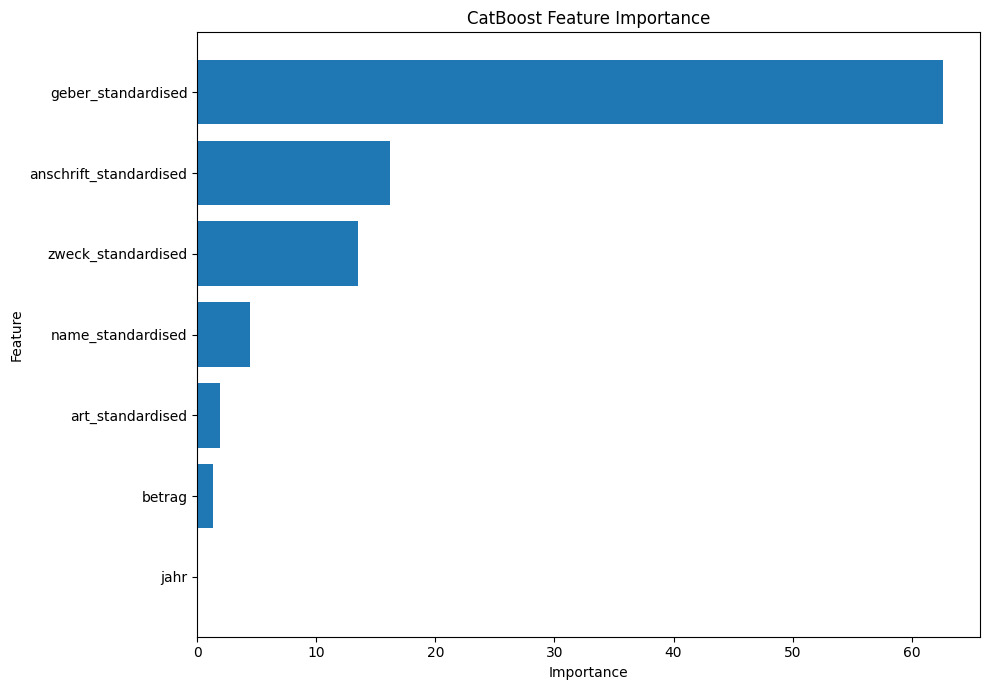

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from catboost import Pool


# CatBoost용 입력 데이터 준비
X_train_catboost = prepare_catboost_features(X_train)

catboost_pool = Pool(
    data=X_train_catboost,
    label=y_train,
    cat_features=catboost_categorical_features,
    text_features=catboost_text_features,
)

# Feature Importance berechnen
feature_importance = catboost_model.get_feature_importance(
    catboost_pool,
    type="PredictionValuesChange",
)

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": X_train_catboost.columns,
            "Importance": feature_importance,
        }
    )
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_importance_df)

# Top Features visualisieren
top_n = 20

plot_df = (
    feature_importance_df
    .head(top_n)
    .sort_values(
        "Importance",
        ascending=True,
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"],
)

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Die Feature-Importance des CatBoost-Modells zeigt, dass `geber_standardised`
mit Abstand den größten Einfluss auf die Vorhersage hat. Dies ist plausibel,
da der Fördergeber häufig bereits stark mit dem Politikbereich verbunden ist.
Gleichzeitig bedeutet dies, dass das Modell möglicherweise nicht nur den
inhaltlichen Zweck der Förderung lernt, sondern auch institutionelle Muster
nutzt.

`zweck_standardised` besitzt ebenfalls eine relevante Bedeutung, liegt jedoch
deutlich hinter `geber_standardised`. Für eine robustere inhaltliche
Klassifikation sollte daher zusätzlich geprüft werden, wie stark die Leistung
ohne `geber_standardised` oder nur mit `zweck_standardised` ausfällt.

### 5.5.5. Ergebnis speichern

Die zusammengefassten Baseline-Ergebnisse werden zusätzlich als CSV-Datei im Projekt gespeichert. Diese Datei kann später im Optuna-Notebook verwendet werden, um zu entscheiden, welche Modelle für das Tuning priorisiert werden.


In [ ]:
baseline_results.to_csv(
    baseline_results_path,
    index=False,
    sep=";",
    encoding="utf-8",
)

baseline_fold_results.to_csv(
    baseline_fold_results_path,
    index=False,
    sep=";",
    encoding="utf-8",
)

print("Gespeichert:", baseline_results_path)
print("Gespeichert:", baseline_fold_results_path)


NameError: name 'baseline_results' is not defined

## 5.6. Feature-Ablation und Repräsentationsexperimente

Die folgenden Experimente bauen auf den Beobachtungen aus der explorativen Datenanalyse auf. Besonders `name` und `anschrift` stehen stark mit der Empfänger-ID in Verbindung und können deshalb als indirekte Identifikationsmerkmale wirken. `zweck` beschreibt dagegen den inhaltlichen Förderzweck und ist damit die fachlich naheliegendste Informationsquelle für den Politikbereich. `geber` kann zusätzlich als administrativer Kontext wirken, während `art`, `jahr` und `betrag` strukturierte Zusatzinformationen darstellen.

Es werden zwei Experimenttypen unterschieden. Bei der **Feature-Ablation** werden einzelne Informationsquellen entfernt oder hinzugefügt, um ihren Beitrag zur Modellleistung zu prüfen. Bei den **Repräsentationsexperimenten** bleibt die Information grundsätzlich erhalten, wird aber anders vorverarbeitet, zum Beispiel `geber` als Textmerkmal oder als kategoriales Merkmal. Damit die Ergebnisse interpretierbar bleiben, wird das Modell festgehalten und nur die verwendeten Spalten bzw. deren Repräsentation werden variiert.


### 5.6.1. Experimentdesign

Die Feature-Ablationen prüfen systematisch den Beitrag einzelner Informationsquellen. Die Repräsentationsexperimente untersuchen dagegen, ob `geber` und `art` besser als Textmerkmale oder als kategoriale Merkmale verarbeitet werden sollten. Das ist besonders für `geber` relevant, weil die Spalte zwar nur wenige Ausprägungen enthält, die Namen der Verwaltungseinheiten aber selbst Begriffe wie Kultur, Wirtschaft oder Europa enthalten können.


In [38]:
ablation_configs = [
    {
        "Ablation": "Full model",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Alle vorgesehenen Merkmalsgruppen",
        "text_features": [
            "name_standardised",
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
    {
        "Ablation": "Zweck only",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Nur inhaltlicher Förderzweck",
        "text_features": [
            "zweck_standardised",
        ],
        "categorical_features": [],
        "numeric_features": [],
    },
    {
        "Ablation": "Zweck + geber text",
        "Experimenttyp": "Repräsentationsexperiment",
        "Beschreibung": "Förderzweck plus Geber als Text",
        "text_features": [
            "zweck_standardised",
            "geber_standardised",
        ],
        "categorical_features": [],
        "numeric_features": [],
    },
    {
        "Ablation": "Zweck + geber category",
        "Experimenttyp": "Repräsentationsexperiment",
        "Beschreibung": "Förderzweck plus Geber als Kategorie",
        "text_features": [
            "zweck_standardised",
        ],
        "categorical_features": [
            "geber_standardised",
        ],
        "numeric_features": [],
    },
    {
        "Ablation": "Ohne Empfängeridentität",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Ohne Name und Anschrift",
        "text_features": [
            "geber_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
    {
        "Ablation": "Ohne Anschrift",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Alle Merkmale außer Anschrift",
        "text_features": [
            "name_standardised",
            "geber_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
    {
        "Ablation": "Ohne Name",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Alle Merkmale außer Name",
        "text_features": [
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
    {
        "Ablation": "Text only",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Nur Textspalten ohne strukturierte Zusatzmerkmale",
        "text_features": [
            "name_standardised",
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [],
        "numeric_features": [],
    },
    {
        "Ablation": "Text + categorical",
        "Experimenttyp": "Feature-Ablation",
        "Beschreibung": "Textspalten plus art und jahr",
        "text_features": [
            "name_standardised",
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [],
    },
    {
        "Ablation": "Full with geber category",
        "Experimenttyp": "Repräsentationsexperiment",
        "Beschreibung": "Geber als Kategorie statt als Text",
        "text_features": [
            "name_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "geber_standardised",
            "art_standardised",
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
    {
        "Ablation": "Full with geber and art as text",
        "Experimenttyp": "Repräsentationsexperiment",
        "Beschreibung": "Geber und art beide als Text",
        "text_features": [
            "name_standardised",
            "geber_standardised",
            "art_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ],
        "categorical_features": [
            "jahr",
        ],
        "numeric_features": [
            "betrag",
        ],
    },
]

ablation_overview = pd.DataFrame(
    [
        {
            "Ablation": config["Ablation"],
            "Experimenttyp": config["Experimenttyp"],
            "Beschreibung": config["Beschreibung"],
            "Textspalten": ", ".join(config["text_features"]),
            "Kategoriale Spalten": ", ".join(config["categorical_features"]),
            "Numerische Spalten": ", ".join(config["numeric_features"]),
        }
        for config in ablation_configs
    ]
)

display(
    ablation_overview.set_index("Ablation")
)


,Experimenttyp,Beschreibung,Textspalten,Kategoriale Spalten,Numerische Spalten
Ablation,,,,,
Full model,Feature-Ablation,Alle vorgesehenen Merkmalsgruppen,"name_standardised, geber_standardised, anschrift_standardised, zweck_standardised","art_standardised, jahr",betrag
Zweck only,Feature-Ablation,Nur inhaltlicher Förderzweck,zweck_standardised,,
Zweck + geber text,Repräsentationsexperiment,Förderzweck plus Geber als Text,"zweck_standardised, geber_standardised",,
Zweck + geber category,Repräsentationsexperiment,Förderzweck plus Geber als Kategorie,zweck_standardised,geber_standardised,
Ohne Empfängeridentität,Feature-Ablation,Ohne Name und Anschrift,"geber_standardised, zweck_standardised","art_standardised, jahr",betrag
Ohne Anschrift,Feature-Ablation,Alle Merkmale außer Anschrift,"name_standardised, geber_standardised, zweck_standardised","art_standardised, jahr",betrag
Ohne Name,Feature-Ablation,Alle Merkmale außer Name,"geber_standardised, anschrift_standardised, zweck_standardised","art_standardised, jahr",betrag
Text only,Feature-Ablation,Nur Textspalten ohne strukturierte Zusatzmerkmale,"name_standardised, geber_standardised, anschrift_standardised, zweck_standardised",,
Text + categorical,Feature-Ablation,Textspalten plus art und jahr,"name_standardised, geber_standardised, anschrift_standardised, zweck_standardised","art_standardised, jahr",


### 5.6.2. Festes Modell für die Experimente auswählen

Für die Feature-Ablation und die Repräsentationsexperimente wird ein Modell festgehalten. Da diese Experimente viele Varianten trainieren, wird nicht automatisch das insgesamt beste Modell gewählt, sondern das beste Modell innerhalb der schnell trainierbaren Baseline-Modelle. Dadurch bleibt die Laufzeit kontrollierbar, während die Auswahl weiterhin datenbasiert über die Hauptmetrik `macro_f1` erfolgt.

Als schnelle Modelle gelten hier Modelle mit einer durchschnittlichen Trainingszeit pro Cross-Validation-Fold von höchstens `max_fast_fit_time_seconds`. Falls für einzelne Modelle noch keine Laufzeit gespeichert wurde, werden bevorzugt die explizit schnellen linearen SGD-Modelle und `ComplementNB` berücksichtigt.


In [37]:
from sklearn.base import clone


max_fast_fit_time_seconds = 5.0
preferred_fast_models = [
    "SGD log loss balanced",
    "SGD hinge balanced",
    "Complement Naive Bayes text only",
]

if "baseline_results" not in globals() or baseline_results.empty:
    raise ValueError(
        "Für die Modellauswahl müssen zuerst die Baseline-Ergebnisse berechnet werden."
    )

baseline_model_candidates = baseline_results[
    baseline_results["Modell"].isin(models.keys())
    & ~baseline_results["Modell"].eq("Dummy Classifier")
].copy()

baseline_model_candidates["fit_time_mean_seconds"] = pd.to_numeric(
    baseline_model_candidates.get(
        "fit_time_mean_seconds",
        pd.Series(
            index=baseline_model_candidates.index,
            dtype="float64",
        ),
    ),
    errors="coerce",
)

measured_fast_candidates = baseline_model_candidates[
    baseline_model_candidates["fit_time_mean_seconds"].le(
        max_fast_fit_time_seconds
    )
].copy()

if measured_fast_candidates.empty:
    fast_model_candidates = baseline_model_candidates[
        baseline_model_candidates["Modell"].isin(
            preferred_fast_models
        )
    ].copy()
else:
    fast_model_candidates = measured_fast_candidates.copy()

if fast_model_candidates.empty:
    raise ValueError(
        "Es wurde kein schnelles Baseline-Modell für die Experimente gefunden."
    )

fast_model_candidates = ensure_val_metric_aliases(
    fast_model_candidates,
    scoring.keys(),
)

fast_model_candidates = fast_model_candidates.sort_values(
    [
        f"val_{main_metric}_mean",
        "fit_time_mean_seconds",
    ],
    ascending=[
        False,
        True,
    ],
    na_position="last",
).reset_index(drop=True)

ablation_model_name = fast_model_candidates.loc[
    0,
    "Modell",
]

base_ablation_classifier = clone(
    models[ablation_model_name].named_steps["classifier"]
)

print("Maximale durchschnittliche Trainingszeit:", max_fast_fit_time_seconds)
print("Schnelle Modellkandidaten:")
display(
    fast_model_candidates[
        [
            "Modell",
            f"val_{main_metric}_mean",
            "fit_time_mean_seconds",
        ]
    ]
)
print("Modell für Feature-Ablation und Repräsentationsexperimente:", ablation_model_name)
print("Classifier:", base_ablation_classifier.__class__.__name__)


Maximale durchschnittliche Trainingszeit: 5.0
Schnelle Modellkandidaten:


,Modell,val_macro_f1_mean,fit_time_mean_seconds
0,SGD hinge balanced,0.8064,3.17
1,SGD log loss balanced,0.7790,3.50
2,Complement Naive Bayes text only,0.6169,3.27


Modell für Feature-Ablation und Repräsentationsexperimente: SGD hinge balanced
Classifier: SGDClassifier


### 5.6.3. Experiment-Pipeline erzeugen

Für jede Variante wird ein eigener `ColumnTransformer` erzeugt. Dadurch können dieselben Spalten je nach Testbedingung unterschiedlich verarbeitet werden, zum Beispiel `geber` als Text oder als kategoriales Merkmal.


In [36]:
def build_ablation_preprocessor(
    selected_text_features,
    selected_categorical_features,
    selected_numeric_features,
):
    """Erstellt einen Preprocessor für eine Ablationsvariante."""
    transformers = []

    transformers.extend(
        [
            (
                f"tfidf_{column}",
                text_transformer,
                [column],
            )
            for column in selected_text_features
        ]
    )

    if selected_categorical_features:
        transformers.append(
            (
                "categorical",
                categorical_transformer,
                selected_categorical_features,
            )
        )

    if selected_numeric_features:
        transformers.append(
            (
                "numeric",
                numeric_transformer,
                selected_numeric_features,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )


def build_ablation_model(config):
    """Kombiniert Ablations-Preprocessor und festes Modell."""
    ablation_preprocessor = build_ablation_preprocessor(
        config["text_features"],
        config["categorical_features"],
        config["numeric_features"],
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                ablation_preprocessor,
            ),
            (
                "classifier",
                clone(base_ablation_classifier),
            ),
        ],
        memory=sklearn_memory,
    )


### 5.6.4. Cross-Validation und MLflow ausführen

Die Ergebnisse werden wie die Baseline-Ergebnisse zwischengespeichert. Bereits vorhandene Varianten werden nicht erneut trainiert. Neue Varianten werden berechnet, an die bestehenden Ergebnisdateien angehängt und zusätzlich in MLflow dokumentiert.


In [ ]:
ablation_results_path = (
    project_root
    / "data"
    / "processed"
    / "ablation_cv_results.csv"
)

ablation_fold_results_path = (
    project_root
    / "data"
    / "processed"
    / "ablation_cv_fold_results.csv"
)

if ablation_results_path.exists():
    existing_ablation_results = pd.read_csv(
        ablation_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    existing_ablation_results = pd.DataFrame()

if ablation_fold_results_path.exists():
    existing_ablation_fold_results = pd.read_csv(
        ablation_fold_results_path,
        sep=";",
        encoding="utf-8",
    )
else:
    existing_ablation_fold_results = pd.DataFrame()

if (
    not existing_ablation_results.empty
    and "Basis_Modell" in existing_ablation_results.columns
):
    valid_existing_ablation_results = existing_ablation_results[
        existing_ablation_results["Basis_Modell"].eq(
            ablation_model_name
        )
    ].copy()
else:
    valid_existing_ablation_results = pd.DataFrame()

# Ergebnisse ohne model_signature werden nicht automatisch wiederverwendet.

experiment_type_by_name = {
    config["Ablation"]: config["Experimenttyp"]
    for config in ablation_configs
}

if (
    not valid_existing_ablation_results.empty
    and "Ablation" in valid_existing_ablation_results.columns
):
    valid_existing_ablation_results["Experimenttyp"] = (
        valid_existing_ablation_results.get(
            "Experimenttyp",
            pd.Series(
                index=valid_existing_ablation_results.index,
                dtype="string",
            ),
        )
        .fillna(
            valid_existing_ablation_results["Ablation"].map(
                experiment_type_by_name
            )
        )
    )

if (
    not existing_ablation_fold_results.empty
    and "Ablation" in existing_ablation_fold_results.columns
):
    existing_ablation_fold_results["Experimenttyp"] = (
        existing_ablation_fold_results.get(
            "Experimenttyp",
            pd.Series(
                index=existing_ablation_fold_results.index,
                dtype="string",
            ),
        )
        .fillna(
            existing_ablation_fold_results["Ablation"].map(
                experiment_type_by_name
            )
        )
    )

new_ablation_rows = []
new_ablation_fold_results = []

for config in tqdm(
    ablation_configs,
    total=len(ablation_configs),
    desc="Feature-Ablation und Repräsentation",
):
    ablation_name = config["Ablation"]

    print("Starte Ablation für:", ablation_name)

    selected_features = (
        config["text_features"]
        + config["categorical_features"]
        + config["numeric_features"]
    )

    X_ablation = X_train[selected_features].copy()
    ablation_model = build_ablation_model(config)
    ablation_model_signature = create_model_signature(
        ablation_model,
        extra_params={
            **signature_run_config,
            "experiment": config["Ablation"],
            "experiment_type": config["Experimenttyp"],
            "selected_features": selected_features,
        },
    )

    signed_ablation_model_name = f"{ablation_model_name}__{ablation_name}"
    has_signed_result = signed_result_exists(
        valid_existing_ablation_results,
        model_column="Ablation",
        model_name=ablation_name,
        model_signature=ablation_model_signature,
    )
    has_signed_model_file, signed_model_path = signed_model_artifact_exists(
        model_name=signed_ablation_model_name,
        model_signature=ablation_model_signature,
        subdirectory="ablation",
    )

    if has_signed_result and has_signed_model_file:
        print(
            "Verwende signiertes Ergebnis und Modell:",
            ablation_name,
            ablation_model_signature,
        )
        continue

    if has_signed_result and not has_signed_model_file:
        print(
            "Signiertes Ablationsergebnis vorhanden, Modell fehlt. "
            "CV wird ?bersprungen, Modell wird neu gefittet:",
            ablation_name,
            ablation_model_signature,
        )
        model_path = fit_and_save_model(
            ablation_model,
            signed_ablation_model_name,
            X_ablation,
            y_train,
            subdirectory="ablation",
            model_signature=ablation_model_signature,
        )
        valid_existing_ablation_results.loc[
            valid_existing_ablation_results["Ablation"].astype(str).eq(str(ablation_name))
            & valid_existing_ablation_results["model_signature"].astype(str).eq(
                str(ablation_model_signature)
            ),
            "model_path",
        ] = str(model_path)
        continue

    if has_signed_model_file and not has_signed_result:
        print(
            "Signiertes Ablationsmodell vorhanden, CV-Ergebnis fehlt. "
            "Es wird nur auf Trainingsdaten evaluiert:",
            ablation_name,
            ablation_model_signature,
        )
        summary_row = evaluate_existing_model_on_training_data(
            signed_model_path,
            ablation_name,
            ablation_model_signature,
            X_ablation,
            y_train,
        )
        summary_row["Ablation"] = summary_row.pop("Modell")
        summary_row["Basis_Modell"] = ablation_model_name
        summary_row["Textspalten"] = ", ".join(config["text_features"])
        summary_row["Kategoriale_Spalten"] = ", ".join(
            config["categorical_features"]
        )
        summary_row["Numerische_Spalten"] = ", ".join(
            config["numeric_features"]
        )
        summary_row["Experimenttyp"] = config["Experimenttyp"]
        summary_row["Beschreibung"] = config["Beschreibung"]
        new_ablation_rows.append(summary_row)
        continue

    print("Starte Ablation f?r:", ablation_name, ablation_model_signature)

    cv_results = cross_validate(
        ablation_model,
        X_ablation,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=CROSS_VALIDATION_N_JOBS,
        return_train_score=True,
    )

    summary_row = create_cv_summary_row(
        ablation_name,
        cv_results,
        model_signature=ablation_model_signature,
    )

    model_path = fit_and_save_model(
        ablation_model,
        f"{ablation_model_name}__{ablation_name}",
        X_ablation,
        y_train,
        subdirectory="ablation",
        model_signature=ablation_model_signature,
    )
    summary_row["model_path"] = str(model_path)
    summary_row["Ablation"] = summary_row.pop("Modell")
    summary_row["Basis_Modell"] = ablation_model_name
    summary_row["Textspalten"] = ", ".join(config["text_features"])
    summary_row["Kategoriale_Spalten"] = ", ".join(
        config["categorical_features"]
    )
    summary_row["Numerische_Spalten"] = ", ".join(
        config["numeric_features"]
    )
    summary_row["Experimenttyp"] = config["Experimenttyp"]
    summary_row["Beschreibung"] = config["Beschreibung"]

    fold_results = create_cv_fold_results_df(
        ablation_name,
        cv_results,
        model_signature=ablation_model_signature,
    ).rename(columns={"model": "Ablation"})
    fold_results.insert(1, "Basis_Modell", ablation_model_name)
    fold_results.insert(2, "Experimenttyp", config["Experimenttyp"])

    with mlflow.start_run(run_name=f"Ablation - {ablation_name}"):
        mlflow.set_tag("stage", "feature_ablation_and_representation")
        mlflow.set_tag("experiment_type", config["Experimenttyp"])
        mlflow.set_tag("main_metric", main_metric)
        mlflow.log_params(
            {
                "experiment_name": ablation_name,
                "experiment_type": config["Experimenttyp"],
                "base_model": ablation_model_name,
                "text_features": summary_row["Textspalten"],
                "categorical_features": summary_row[
                    "Kategoriale_Spalten"
                ],
                "numeric_features": summary_row["Numerische_Spalten"],
                "cv_folds": n_splits,
                "model_signature": ablation_model_signature,
            }
        )

        for metric_name, metric_value in pd.Series(summary_row).items():
            if (
                metric_name.endswith("_mean")
                or metric_name.endswith("_std")
                or metric_name.endswith("_seconds")
            ) and pd.notna(metric_value):
                mlflow.log_metric(metric_name, float(metric_value))

        with tempfile.TemporaryDirectory() as temporary_directory:
            artifact_path = Path(temporary_directory) / "ablation_fold_results.csv"
            fold_results.to_csv(
                artifact_path,
                index=False,
                sep=";",
                encoding="utf-8",
            )
            mlflow.log_artifact(
                str(artifact_path),
                artifact_path="cross_validation",
            )

    new_ablation_rows.append(summary_row)
    new_ablation_fold_results.append(fold_results)

if new_ablation_rows:
    ablation_results = pd.concat(
        [
            valid_existing_ablation_results,
            pd.DataFrame(new_ablation_rows),
        ],
        ignore_index=True,
    )
else:
    ablation_results = existing_ablation_results.copy()

if new_ablation_fold_results:
    ablation_fold_results = pd.concat(
        [
            existing_ablation_fold_results,
            *new_ablation_fold_results,
        ],
        ignore_index=True,
    )
else:
    ablation_fold_results = existing_ablation_fold_results.copy()

ablation_results = ensure_val_metric_aliases(
    ablation_results,
    scoring.keys(),
)

ablation_results = (
    ablation_results
    .drop_duplicates(
        subset=["Ablation", "model_signature"],
        keep="last",
    )
    .sort_values(
        f"val_{main_metric}_mean",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

ablation_fold_results = (
    ablation_fold_results
    .drop_duplicates(
        subset=["Ablation", "model_signature", "fold"],
        keep="last",
    )
    .reset_index(drop=True)
)

display_model_evaluation_table(
    ablation_results,
    model_column_candidates=[
        "Ablation",
        "Basis_Modell",
    ],
    include_columns=[
        "Experimenttyp",
    ],
    metric_prefixes=[
        "train_",
        "val_",
    ],
    sort_by=f"val_{main_metric}_mean",
    ascending=False,
)


Feature-Ablation und Repräsentation:   0%|          | 0/11 [00:00<?, ?it/s]

Starte Ablation für: Full model
Starte Ablation f?r: Full model 3469d860060e


Feature-Ablation und Repräsentation:   9%|▉         | 1/11 [00:42<07:05, 42.52s/it]

Starte Ablation für: Zweck only
Starte Ablation f?r: Zweck only 7a6b71ee5cd8


Feature-Ablation und Repräsentation:  18%|█▊        | 2/11 [00:58<04:00, 26.77s/it]

...

Starte Ablation für: Full with geber category
Starte Ablation f?r: Full with geber category 603e8d774496


Feature-Ablation und Repräsentation:  91%|█████████ | 10/11 [05:22<00:36, 36.83s/it]

Starte Ablation für: Full with geber and art as text
Starte Ablation f?r: Full with geber and art as text d5d8e9fed161


Feature-Ablation und Repräsentation: 100%|██████████| 11/11 [06:05<00:00, 33.22s/it]


,Experimenttyp,Basis_Modell,fit_time_total_seconds,fit_time_mean_seconds,fit_time_std_seconds,score_time_mean_seconds,train_macro_f1_mean,train_macro_f1_std,generalization_gap_macro_f1,train_weighted_f1_mean,...,train_accuracy_std,generalization_gap_accuracy,val_macro_f1_mean,val_macro_f1_std,val_weighted_f1_mean,val_weighted_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std,val_accuracy_mean,val_accuracy_std
Ablation,,,,,,,,,,,,,,,,,,,,,
Text + categorical,Feature-Ablation,SGD hinge balanced,10.84,2.71,0.09,0.76,0.9193,0.0104,0.1023,0.9679,...,0.0024,0.0460,0.8170,0.0132,0.9229,0.0009,0.8548,0.0095,0.9209,0.0016
Text + categorical,Feature-Ablation,SGD hinge balanced,22.14,5.54,0.17,0.69,0.9174,0.0104,0.1024,0.9657,...,0.0018,0.0442,0.8150,0.0088,0.9222,0.0009,0.8508,0.0102,0.9208,0.0009
Full with geber category,Repräsentationsexperiment,SGD hinge balanced,9.04,2.26,0.11,0.59,0.9071,0.0135,0.0954,0.9678,...,0.0024,0.0453,0.8117,0.0147,0.9231,0.0023,0.8468,0.0111,0.9216,0.0025
Full model,Feature-Ablation,SGD hinge balanced,24.07,6.02,0.19,0.72,0.9119,0.0221,0.1055,0.9639,...,0.0052,0.0448,0.8064,0.0326,0.9198,0.0036,0.8382,0.0215,0.9179,0.0050
Full model,Feature-Ablation,SGD hinge balanced,10.30,2.57,0.09,0.75,0.9108,0.0191,0.1046,0.9669,...,0.0045,0.0456,0.8062,0.0209,0.9220,0.0037,0.8381,0.0209,0.9201,0.0045
Text only,Feature-Ablation,SGD hinge balanced,9.10,2.28,0.09,0.73,0.9039,0.0143,0.1019,0.9708,...,0.0010,0.0459,0.8020,0.0080,0.9256,0.0016,0.8574,0.0137,0.9240,0.0019
Text + categorical,Feature-Ablation,SGD hinge balanced,9.11,3.04,0.14,0.98,0.9137,0.0087,0.1143,0.9666,...,0.0008,0.0487,0.7994,0.0064,0.9184,0.0034,0.8421,0.0109,0.9173,0.0041
Text only,Feature-Ablation,SGD hinge balanced,19.49,4.87,0.12,0.68,0.9068,0.0136,0.1080,0.9680,...,0.0004,0.0454,0.7988,0.0092,0.9234,0.0018,0.8544,0.0212,0.9218,0.0020
Ohne Anschrift,Feature-Ablation,SGD hinge balanced,22.32,5.58,0.11,0.66,0.9028,0.0255,0.1042,0.9612,...,0.0023,0.0423,0.7986,0.0251,0.9198,0.0027,0.8371,0.0170,0.9177,0.0032


In [ ]:
# Bestes Szenario anhand der Hauptmetrik auswählen.
best_scenario = (
    ablation_results
    .sort_values(
        f"val_{main_metric}_mean",
        ascending=False,
        na_position="last",
    )
    .iloc[0]
)

best_scenario_name = best_scenario["Ablation"]

best_scenario_config = next(
    config
    for config in ablation_configs
    if config["Ablation"] == best_scenario_name
)

best_scenario_columns = (
    best_scenario_config["text_features"]
    + best_scenario_config["categorical_features"]
    + best_scenario_config["numeric_features"]
)

best_scenario_columns_df = pd.DataFrame(
    {
        "Trainingsspalte": best_scenario_columns
    }
)

all_model_columns = (
    text_features
    + categorical_features
    + numeric_features
)

missing_columns = [
    column
    for column in all_model_columns
    if column not in best_scenario_columns
]

missing_columns_df = pd.DataFrame(
    {
        "Nicht verwendete Trainingsspalte": missing_columns
    }
)

print("Bestes Szenario:", best_scenario_name)
print(
    "Val-Macro-F1:",
    round(best_scenario[f"val_{main_metric}_mean"], 4),
)

display(best_scenario_columns_df)


print("Bestes Szenario:", best_scenario_name)

print(
    "Anzahl verwendeter Spalten:",
    len(best_scenario_columns),
)

print(
    "Anzahl nicht verwendeter Spalten:",
    len(missing_columns),
)

display(missing_columns_df)

Bestes Szenario: Text + categorical
Val-Macro-F1: 0.817


,Trainingsspalte
0,name_standardised
1,geber_standardised
2,anschrift_standardised
3,zweck_standardised
4,art_standardised
5,jahr


Bestes Szenario: Text + categorical
Anzahl verwendeter Spalten: 6
Anzahl nicht verwendeter Spalten: 1


,Nicht verwendete Trainingsspalte
0,betrag


### 5.6.5. Kontrollvergleich mit Linear SVC

Zur Prüfung der Ablationsergebnisse wird zusätzlich ein Kontrollvergleich mit `Linear SVC` durchgeführt. Dabei bleibt das Modell konstant: Es wird immer dasselbe lineare SVM-Modell verwendet. Verändert werden nur die verwendeten Eingabespalten. Verglichen wird das vollständige Ausgangsszenario mit dem besten Szenario aus der Feature-Ablation bzw. den Repräsentationsexperimenten.

Damit lässt sich prüfen, ob die beobachtete Verbesserung tatsächlich auf die veränderte Datengrundlage zurückzuführen ist und nicht nur auf Unterschiede zwischen verschiedenen Modelltypen. Da `Linear SVC` in den Baseline-Ergebnissen zu den stärksten Modellen gehört, ist dieser Kontrollvergleich besonders relevant für die spätere Modellauswahl.

In [41]:
from pathlib import Path

project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

processed_data_dir = project_root / "data" / "processed"

In [42]:
RUN_LINEAR_SVC_CONTROL_COMPARISON = globals().get(
    "RUN_LINEAR_SVC_CONTROL_COMPARISON",
    True,
)

if "ablation_results" not in globals():
    ablation_results_path = (
        processed_data_dir
        / "ablation_cv_results.csv"
    )

    ablation_results = pd.read_csv(
        ablation_results_path,
        sep=";",
        encoding="utf-8",
    )

    ablation_results = ensure_val_metric_aliases(
        ablation_results,
        scoring.keys(),
    )

if RUN_LINEAR_SVC_CONTROL_COMPARISON:
    linear_svc_control_model_name = "Linear SVC unweighted"

    if linear_svc_control_model_name not in models:
        raise KeyError(
            f"Das Kontrollmodell '{linear_svc_control_model_name}' "
            "wurde nicht in models definiert."
        )

    linear_svc_control_classifier = clone(
        models[
            linear_svc_control_model_name
        ].named_steps["classifier"]
    )

    best_scenario_row = (
        ablation_results
        .sort_values(
            f"val_{main_metric}_mean",
            ascending=False,
        )
        .iloc[0]
    )

    best_scenario_name = best_scenario_row["Ablation"]

    full_scenario_config = next(
        config
        for config in ablation_configs
        if config["Ablation"] == "Full model"
    )

    best_scenario_config = next(
        config
        for config in ablation_configs
        if config["Ablation"] == best_scenario_name
    )

    linear_svc_control_configs = [
        (
            "Full model",
            full_scenario_config,
        ),
    ]

    if best_scenario_name != "Full model":
        linear_svc_control_configs.append(
            (
                "Best scenario",
                best_scenario_config,
            )
        )
    else:
        print(
            "Das beste Szenario entspricht bereits "
            "dem vollständigen Modell."
        )

    linear_svc_control_rows = []

    for scenario_label, scenario_config in linear_svc_control_configs:
        scenario_features = (
            scenario_config["text_features"]
            + scenario_config["categorical_features"]
            + scenario_config["numeric_features"]
        )

        scenario_preprocessor = build_ablation_preprocessor(
            scenario_config["text_features"],
            scenario_config["categorical_features"],
            scenario_config["numeric_features"],
        )

        scenario_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    scenario_preprocessor,
                ),
                (
                    "classifier",
                    clone(linear_svc_control_classifier),
                ),
            ]
        )

        scenario_cv_results = cross_validate(
            scenario_model,
            X_train[scenario_features].copy(),
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=True,
        )

        scenario_summary = create_cv_summary_row(
            scenario_label,
            scenario_cv_results,
        )

        scenario_summary["Szenario"] = scenario_label
        scenario_summary["Ablation"] = scenario_config["Ablation"]
        scenario_summary["Experimenttyp"] = scenario_config[
            "Experimenttyp"
        ]
        scenario_summary["Modell"] = linear_svc_control_model_name
        scenario_summary["Anzahl_Trainingsspalten"] = len(
            scenario_features
        )
        scenario_summary["Trainingsspalten"] = ", ".join(
            scenario_features
        )

        linear_svc_control_rows.append(scenario_summary)

    linear_svc_control_results = pd.DataFrame(
        linear_svc_control_rows
    )

    linear_svc_control_results = ensure_val_metric_aliases(
        linear_svc_control_results,
        scoring.keys(),
    )

    if "Full model" in linear_svc_control_results["Szenario"].values:
        full_metric_value = linear_svc_control_results.loc[
            linear_svc_control_results["Szenario"].eq("Full model"),
            f"val_{main_metric}_mean",
        ].iloc[0]

        linear_svc_control_results[
            f"Differenz_zu_Full_model_{main_metric}"
        ] = (
            linear_svc_control_results[f"val_{main_metric}_mean"]
            - full_metric_value
        ).round(4)

    linear_svc_control_metric_columns = (
        select_validation_result_columns(
            linear_svc_control_results,
            extra_columns=[
                "Modell",
                "Ablation",
                "Experimenttyp",
                "Anzahl_Trainingsspalten",
                f"Differenz_zu_Full_model_{main_metric}",
            ],
        )
    )

    display(
        linear_svc_control_results
        .set_index("Szenario")
        [linear_svc_control_metric_columns]
    )

    best_scenario_train_columns = pd.DataFrame(
        {
            "Trainingsspalte": (
                best_scenario_config["text_features"]
                + best_scenario_config["categorical_features"]
                + best_scenario_config["numeric_features"]
            )
        }
    )

    print("Bestes Szenario:", best_scenario_name)
    display(best_scenario_train_columns)

else:
    print(
        "Kontrollvergleich mit Linear SVC wird übersprungen."
    )

,Modell,Ablation,Experimenttyp,Anzahl_Trainingsspalten,Differenz_zu_Full_model_macro_f1,fit_time_total_seconds,fit_time_mean_seconds,fit_time_std_seconds,score_time_mean_seconds,val_macro_f1_mean,val_macro_f1_std,train_macro_f1_mean,train_macro_f1_std,generalization_gap_macro_f1,val_weighted_f1_mean,val_weighted_f1_std,train_weighted_f1_mean,train_weighted_f1_std,generalization_gap_weighted_f1,val_balanced_accuracy_mean,val_balanced_accuracy_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,generalization_gap_balanced_accuracy,val_accuracy_mean,val_accuracy_std,train_accuracy_mean,train_accuracy_std,generalization_gap_accuracy
Szenario,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Full model,Linear SVC unweighted,Full model,Feature-Ablation,7,0.0000,103.85,25.96,6.26,0.95,0.8233,0.0189,0.9419,0.0014,0.1186,0.9251,0.0015,0.9711,0.0003,0.0460,0.7945,0.0226,0.9186,0.0027,0.1241,0.9267,0.0014,0.9714,0.0003,0.0447
Best scenario,Linear SVC unweighted,Text + categorical,Feature-Ablation,6,0.0008,22.21,5.55,0.35,1.01,0.8241,0.0200,0.9418,0.0014,0.1177,0.9247,0.0013,0.9711,0.0004,0.0464,0.7953,0.0229,0.9184,0.0026,0.1231,0.9263,0.0011,0.9714,0.0003,0.0451


Bestes Szenario: Text + categorical


,Trainingsspalte
0,name_standardised
1,geber_standardised
2,anschrift_standardised
3,zweck_standardised
4,art_standardised
5,jahr


### 5.6.6. Ergebnisse speichern

Die Ergebnisse werden gespeichert, damit spätere Notebook-Läufe bereits berechnete Varianten wiederverwenden können. Die besten Merkmals- und Repräsentationsentscheidungen dienen anschließend als Grundlage für die Hyperparameteroptimierung mit Optuna.


In [43]:
ablation_results.to_csv(
    ablation_results_path,
    index=False,
    sep=";",
    encoding="utf-8",
)

ablation_fold_results.to_csv(
    ablation_fold_results_path,
    index=False,
    sep=";",
    encoding="utf-8",
)

print("Gespeichert:", ablation_results_path)
print("Gespeichert:", ablation_fold_results_path)


NameError: name 'ablation_fold_results' is not defined